# Dataset Statistics Report

This notebook generates comprehensive statistics for:
- **4.1.1** DECORTE Dataset
- **4.1.3** ESCO Taxonomy
- **4.1.4** Exploratory Data Analysis


## Setup and Imports


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
PROJECT_ROOT = Path("../..")
DATA_DIR = PROJECT_ROOT / "data"
ESCO_DIR = DATA_DIR / "esco_datasets"

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"ESCO data dir: {ESCO_DIR.resolve()}")


Project root: /dss/dsshome1/02/ra95kix2/thesis/skills4cpp
ESCO data dir: /dss/dsshome1/02/ra95kix2/thesis/skills4cpp/data/esco_datasets


## Load ESCO Datasets


In [3]:
# Load all ESCO datasets
skills = pd.read_csv(ESCO_DIR / "skills_en.csv", low_memory=False)
occupations = pd.read_csv(ESCO_DIR / "occupations_en.csv", low_memory=False)
occ_skill_relations = pd.read_csv(ESCO_DIR / "occupationSkillRelations_en.csv", low_memory=False)
skill_groups = pd.read_csv(ESCO_DIR / "skillGroups_en.csv", low_memory=False)
skill_hierarchy = pd.read_csv(ESCO_DIR / "skillsHierarchy_en.csv", low_memory=False)
broader_relations = pd.read_csv(ESCO_DIR / "broaderRelationsSkillPillar_en.csv", low_memory=False)
isco_groups = pd.read_csv(ESCO_DIR / "ISCOGroups_en.csv", low_memory=False)

print("ESCO Datasets Loaded:")
print(f"  ✓ Skills: {len(skills):,}")
print(f"  ✓ Occupations: {len(occupations):,}")
print(f"  ✓ Occupation-Skill Relations: {len(occ_skill_relations):,}")
print(f"  ✓ Skill Groups: {len(skill_groups):,}")
print(f"  ✓ Skill Hierarchy: {len(skill_hierarchy):,}")
print(f"  ✓ Broader Relations: {len(broader_relations):,}")
print(f"  ✓ ISCO Groups: {len(isco_groups):,}")


ESCO Datasets Loaded:
  ✓ Skills: 13,939
  ✓ Occupations: 3,039
  ✓ Occupation-Skill Relations: 129,004
  ✓ Skill Groups: 640
  ✓ Skill Hierarchy: 640
  ✓ Broader Relations: 20,822
  ✓ ISCO Groups: 619


## Load DECORTE Dataset


In [4]:
# Load DECORTE dataset from HuggingFace
decorte_dataset = load_dataset("jensjorisdecorte/anonymous-working-histories")

print("DECORTE Dataset Loaded:")
print(f"  ✓ Train: {len(decorte_dataset['train']):,}")
print(f"  ✓ Validation: {len(decorte_dataset['validation']):,}")
print(f"  ✓ Test: {len(decorte_dataset['test']):,}")


DECORTE Dataset Loaded:
  ✓ Train: 1,720
  ✓ Validation: 217
  ✓ Test: 227


---
# 4.1.1 DECORTE Dataset Statistics


### Total number of career histories (resumes)


In [5]:
total_careers = len(decorte_dataset['train']) + len(decorte_dataset['validation']) + len(decorte_dataset['test'])
print(f"Total number of career histories (resumes): {total_careers:,}")


Total number of career histories (resumes): 2,164


### Total number of job experiences


In [6]:
total_job_experiences = 0
for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        total_job_experiences += example['number_of_experiences']

print(f"Total number of job experiences: {total_job_experiences:,}")


Total number of job experiences: 9,919


In [7]:
# Extract all title_k, description_k pairs from the training dataset
all_title_description_pairs = []
for example in decorte_dataset['train']:
    num_experiences = example['number_of_experiences']
    for k in range(num_experiences):
        title = example.get(f'title_{k}')
        description = example.get(f'description_{k}')
        esco = example.get(f'ESCO_uri_{k}')
        split = 'train'
        all_title_description_pairs.append([title, description, esco, split])

for example in decorte_dataset['validation']:
    num_experiences = example['number_of_experiences']
    for k in range(num_experiences):
        title = example.get(f'title_{k}')
        description = example.get(f'description_{k}')
        esco = example.get(f'ESCO_uri_{k}')
        split='val'
        all_title_description_pairs.append([title, description, esco, split])

for example in decorte_dataset['test']:
    num_experiences = example['number_of_experiences']
    for k in range(num_experiences):
        title = example.get(f'title_{k}')
        description = example.get(f'description_{k}')
        esco = example.get(f'ESCO_uri_{k}')
        split='test'
        all_title_description_pairs.append([title, description, esco,split])

In [8]:
unique_exp = len(set(tuple(pair) for pair in all_title_description_pairs))

print(f"Unique number of job experiences: {unique_exp:,}")


Unique number of job experiences: 9,885


In [9]:
# quick analysis

all_title_description_pairs

[['Line Cook',
  '- Prepped food for the line and cooked appetizers, soups, sandwiches, and fried foods\n- Detail cleaned the kitchen\n- Developed strong communication skills in a fast-paced kitchen environment',
  'http://data.europa.eu/esco/occupation/90f75f67-495d-49fa-ab57-2f320e251d7e',
  'train'],
 ['Line Cook',
  '- Prepared food for the line and cooked a variety of dishes\n- Created daily specials and closed the restaurant\n- Ensured the kitchen was cleaned in detail and trained new cooks\n- Developed strong multi-tasking skills by working alone in a busy kitchen',
  'http://data.europa.eu/esco/occupation/90f75f67-495d-49fa-ab57-2f320e251d7e',
  'train'],
 ['Line Chef',
  '- Prepared food for the kitchen and created specials for the dinner and lunch menu\n- Cooked food for large banquets, including weddings, up to 300 people\n- Trained new cooks and cooked breakfast, lunch, and dinner\n- Ensured the kitchen was cleaned in detail\n- Developed knowledge of building each dish from

### Train/val/test split sizes


In [10]:
train_size = len(decorte_dataset['train'])
val_size = len(decorte_dataset['validation'])
test_size = len(decorte_dataset['test'])

print("Train/Val/Test Split Sizes:")
print(f"  Train: {train_size:,} ({train_size/total_careers*100:.1f}%)")
print(f"  Validation: {val_size:,} ({val_size/total_careers*100:.1f}%)")
print(f"  Test: {test_size:,} ({test_size/total_careers*100:.1f}%)")


Train/Val/Test Split Sizes:
  Train: 1,720 (79.5%)
  Validation: 217 (10.0%)
  Test: 227 (10.5%)


### Career length statistics (jobs per career)


In [11]:
# Collect all career lengths
all_career_lengths = []
for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        all_career_lengths.append(example['number_of_experiences'])

avg_career_length = np.mean(all_career_lengths)
std_career_length = np.std(all_career_lengths)
min_career_length = min(all_career_lengths)
max_career_length = max(all_career_lengths)
median_career_length = np.median(all_career_lengths)

print("Career Length Statistics:")
print(f"  Average: {avg_career_length:.2f} jobs per career")
print(f"  Std Dev: {std_career_length:.2f}")
print(f"  Min: {min_career_length}")
print(f"  Max: {max_career_length}")
print(f"  Median: {median_career_length:.1f}")


Career Length Statistics:
  Average: 4.58 jobs per career
  Std Dev: 1.92
  Min: 2
  Max: 17
  Median: 4.0


### Career length distribution (with visualization)


Career Length Distribution:
  2 jobs: 96 (4.4%)
  3 jobs: 579 (26.8%)
  4 jobs: 704 (32.5%)
  5 jobs: 263 (12.2%)
  6 jobs: 195 (9.0%)
  7 jobs: 145 (6.7%)
  8 jobs: 81 (3.7%)
  9 jobs: 47 (2.2%)
  10 jobs: 29 (1.3%)
  11 jobs: 9 (0.4%)
  12 jobs: 5 (0.2%)
  13 jobs: 5 (0.2%)
  14 jobs: 3 (0.1%)
  15 jobs: 2 (0.1%)
  17 jobs: 1 (0.0%)


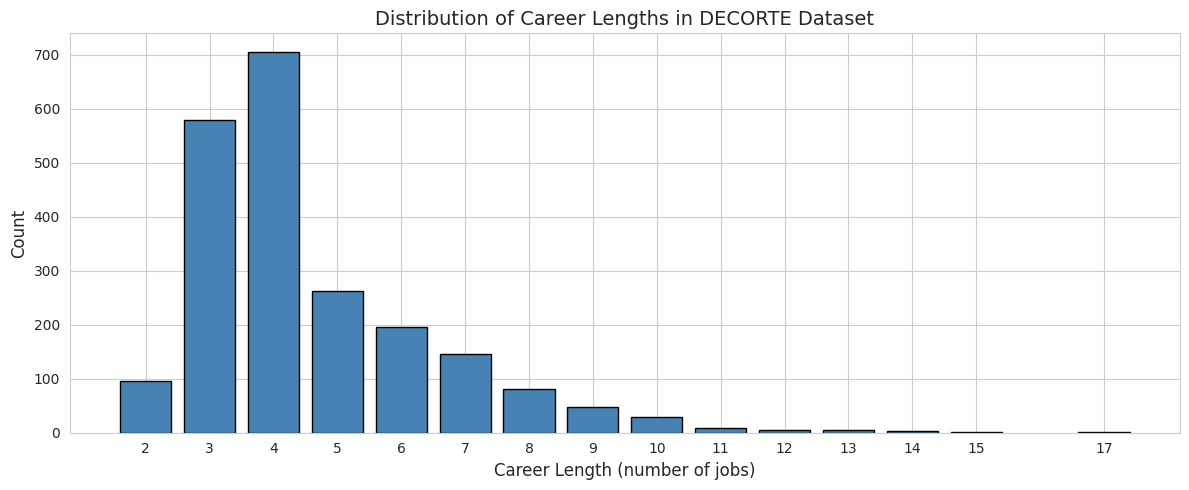

In [12]:
career_length_dist = Counter(all_career_lengths)

print("Career Length Distribution:")
for length in sorted(career_length_dist.keys()):
    count = career_length_dist[length]
    pct = count / len(all_career_lengths) * 100
    print(f"  {length} jobs: {count:,} ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
lengths = sorted(career_length_dist.keys())
counts = [career_length_dist[l] for l in lengths]
ax.bar(lengths, counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Career Length (number of jobs)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Career Lengths in DECORTE Dataset', fontsize=14)
ax.set_xticks(lengths)
plt.tight_layout()
plt.show()


### Number of unique ESCO occupations in dataset


In [13]:
all_esco_uris = set()
for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        n_exp = example['number_of_experiences']
        for i in range(n_exp):
            uri = example.get(f'ESCO_uri_{i}')
            if uri and not pd.isna(uri):
                all_esco_uris.add(uri)

print(f"Number of unique ESCO occupations appearing in dataset: {len(all_esco_uris):,}")
print(f"Coverage of ESCO taxonomy: {len(all_esco_uris)/len(occupations)*100:.1f}%")


Number of unique ESCO occupations appearing in dataset: 1,155
Coverage of ESCO taxonomy: 38.0%


In [78]:
all_esco_uris

{'http://data.europa.eu/esco/occupation/976cbfcc-8958-4800-a435-71d15405a42a',
 'http://data.europa.eu/esco/occupation/d18deca3-3063-4970-9ddc-e3c70404a28c',
 'http://data.europa.eu/esco/occupation/5979893a-0a30-447b-8f33-1ea405600583',
 'http://data.europa.eu/esco/occupation/c9862fdd-53b7-4da9-b742-4302d704836c',
 'http://data.europa.eu/esco/occupation/c9874f14-5474-43f6-b4a2-77a94f9abfb3',
 'http://data.europa.eu/esco/occupation/a950e88b-cb5e-4a7d-8a94-3f9460b487d7',
 'http://data.europa.eu/esco/occupation/58ff0ec2-08ba-4b21-b765-babb6d76ca36',
 'http://data.europa.eu/esco/occupation/5ccb2c34-e860-43a5-9869-342487518115',
 'http://data.europa.eu/esco/occupation/49e28648-4fa8-4b36-ac4d-781c108547bf',
 'http://data.europa.eu/esco/occupation/c94dc5b2-6b23-4915-8de5-a4e6ae86d802',
 'http://data.europa.eu/esco/occupation/9a39a143-d93c-4093-ba3b-47fb67ade318',
 'http://data.europa.eu/esco/occupation/3a8a7f87-d394-42cd-804b-7a32375b90f0',
 'http://data.europa.eu/esco/occupation/326027fc-540

### ESCO version used


In [14]:
# Determine ESCO version from file dates
if 'modifiedDate' in occupations.columns:
    dates = pd.to_datetime(occupations['modifiedDate'], errors='coerce')
    most_recent = dates.max()
    esco_version = f"v1.2.0 (files dated {most_recent.strftime('%Y-%m')})"
else:
    esco_version = "v1.2.0 (estimated)"

print(f"ESCO version used: {esco_version}")


ESCO version used: v1.2.0 (files dated 2024-04)


---
# 4.1.3 ESCO Taxonomy Statistics


### Total number of occupations


In [15]:
total_occupations = len(occupations)
print(f"Total number of occupations: {total_occupations:,}")


Total number of occupations: 3,039


### Total number of skills


In [16]:
total_skills = len(skills)
print(f"Total number of skills: {total_skills:,}")
print(f"# of skills mapped to an occupation: {occ_skill_relations.skillUri.nunique()}")

# Breakdown by skill type
skill_type_counts = skills['skillType'].value_counts()
print("\nBreakdown by skill type:")
for skill_type, count in skill_type_counts.items():
    print(f"  {skill_type}: {count:,}")


Total number of skills: 13,939
# of skills mapped to an occupation: 13492

Breakdown by skill type:
  skill/competence: 10,715
  knowledge: 3,219


### Number of essential vs optional skill relations


Occupation-Skill Relations:
  Total: 129,004
  Essential: 67,622 (52.4%)
  Optional: 61,382 (47.6%)


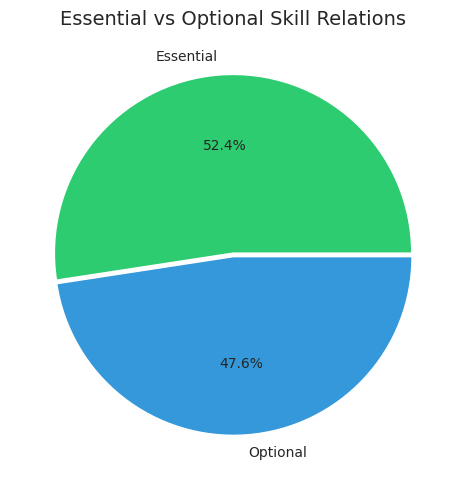

In [17]:
essential_mask = occ_skill_relations['relationType'] == 'essential'
essential_relations = essential_mask.sum()
optional_relations = (~essential_mask).sum()
total_relations = len(occ_skill_relations)

print("Occupation-Skill Relations:")
print(f"  Total: {total_relations:,}")
print(f"  Essential: {essential_relations:,} ({essential_relations/total_relations*100:.1f}%)")
print(f"  Optional: {optional_relations:,} ({optional_relations/total_relations*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
ax.pie([essential_relations, optional_relations], 
       labels=['Essential', 'Optional'],
       autopct='%1.1f%%',
       colors=['#2ecc71', '#3498db'],
       explode=(0.02, 0))
ax.set_title('Essential vs Optional Skill Relations', fontsize=14)
plt.tight_layout()
plt.show()


### Average skills per occupation (essential only, optional only, combined)


In [18]:
# Combined (all skills)
skills_per_occ = occ_skill_relations.groupby('occupationUri')['skillUri'].nunique()

# Essential only
essential_per_occ = occ_skill_relations[essential_mask].groupby('occupationUri')['skillUri'].nunique()

# Optional only
optional_per_occ = occ_skill_relations[~essential_mask].groupby('occupationUri')['skillUri'].nunique()

print("Skills per Occupation:")
print(f"\n  Combined (Essential + Optional):")
print(f"    Average: {skills_per_occ.mean():.2f}")
print(f"    Std Dev: {skills_per_occ.std():.2f}")
print(f"    Min: {skills_per_occ.min()}")
print(f"    Max: {skills_per_occ.max()}")
print(f"    Median: {skills_per_occ.median():.1f}")

print(f"\n  Essential Only:")
print(f"    Average: {essential_per_occ.mean():.2f}")

print(f"\n  Optional Only:")
print(f"    Average: {optional_per_occ.mean():.2f}")


Skills per Occupation:

  Combined (Essential + Optional):
    Average: 42.44
    Std Dev: 25.75
    Min: 7
    Max: 345
    Median: 37.0

  Essential Only:
    Average: 22.25

  Optional Only:
    Average: 21.48


In [19]:
# Calculate percentiles for skills per occupation
percentiles = [10, 25, 50, 75, 90, 95, 99]
print("\nSkills per Occupation - Percentiles:")
for p in percentiles:
    value = skills_per_occ.quantile(p/100)
    print(f"  {p}th percentile: {value:.1f}")



Skills per Occupation - Percentiles:
  10th percentile: 22.0
  25th percentile: 28.0
  50th percentile: 37.0
  75th percentile: 49.0
  90th percentile: 71.0
  95th percentile: 86.0
  99th percentile: 122.6


### Skills per occupation distribution (visualization)


In [1]:
import pandas as pd
df_h = pd.read_csv(r'/dss/dsshome1/02/ra95kix2/thesis/skills4cpp/data/processed/master_datasets_2/master_skill_complete_hierarchy.csv')

In [2]:
df_h.level1_label.nunique()

27

In [3]:
df_h.level2_label.nunique()

207

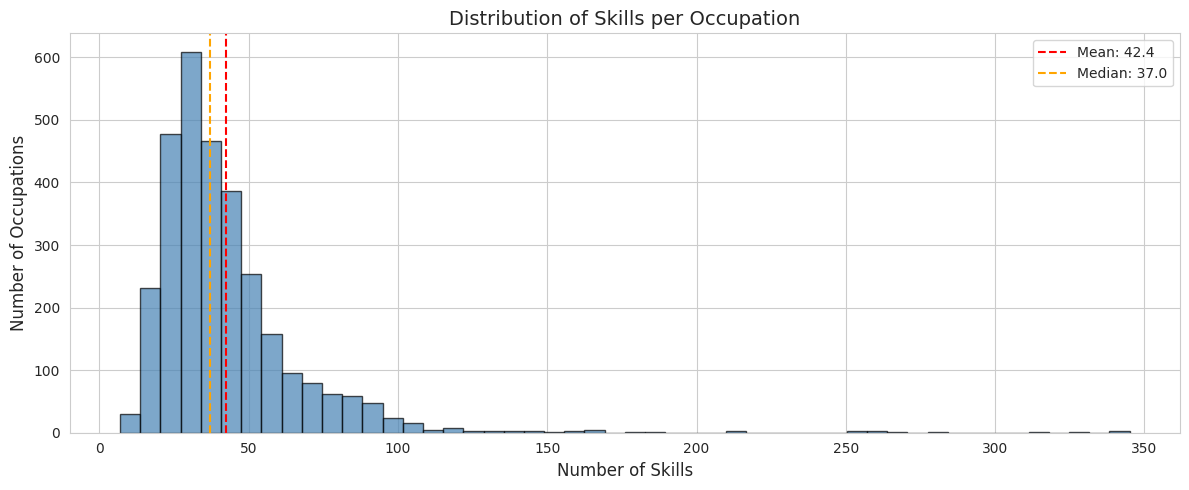

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(skills_per_occ, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(skills_per_occ.mean(), color='red', linestyle='--', label=f'Mean: {skills_per_occ.mean():.1f}')
ax.axvline(skills_per_occ.median(), color='orange', linestyle='--', label=f'Median: {skills_per_occ.median():.1f}')
ax.set_xlabel('Number of Skills', fontsize=12)
ax.set_ylabel('Number of Occupations', fontsize=12)
ax.set_title('Distribution of Skills per Occupation', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


### Number of L1 and L2 skill categories


In [22]:
# Count L1 categories (Level 1 URI is not null, Level 2 is null)
l1_mask = skill_hierarchy['Level 1 URI'].notna() & skill_hierarchy['Level 2 URI'].isna()
num_l1_categories = df_h.level1_label.nunique()

# Count L2 categories
l2_mask = skill_hierarchy['Level 2 URI'].notna() & skill_hierarchy['Level 3 URI'].isna()
num_l2_categories = df_h.level2_label.nunique()

print("Skill Hierarchy Levels:")
print(f"  L1 skill categories (pillars): {num_l1_categories}")
print(f"  L2 skill categories: {num_l2_categories}")

# Show L1 categories
print("\nL1 Categories (Pillars):")
l1_categories = skill_hierarchy[l1_mask][['Level 1 URI', 'Level 1 preferred term']].drop_duplicates()
for _, row in l1_categories.iterrows():
    print(f"  - {row['Level 1 preferred term']}")


Skill Hierarchy Levels:
  L1 skill categories (pillars): 27
  L2 skill categories: 207

L1 Categories (Pillars):
  - languages
  - classical languages
  - handling and moving
  - information skills
  - working with computers
  - constructing
  - management skills
  - working with machinery and specialised equipment
  - assisting and caring
  - communication, collaboration and creativity
  - self-management skills and competences
  - physical and manual skills and competences
  - life skills and competences
  - social and communication skills and competences
  - thinking skills and competences
  - core skills and competences
  - generic programmes and qualifications
  - education
  - arts and humanities
  - social sciences, journalism and information
  - business, administration and law
  - natural sciences, mathematics and statistics
  - information and communication technologies (icts)
  - engineering, manufacturing and construction
  - agriculture, forestry, fisheries and veterinary


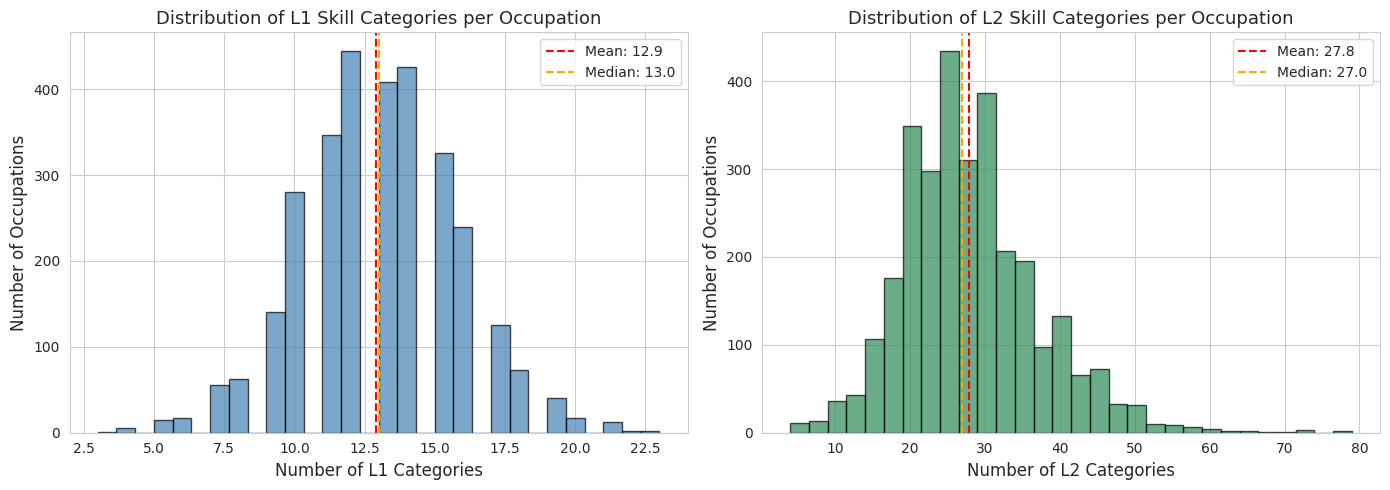

L1 categories per occupation - Mean: 12.89, Median: 13, Max: 23
L2 categories per occupation - Mean: 27.81, Median: 27, Max: 79


In [23]:
# Distribution of L1 and L2 skill categories per occupation
import seaborn as sns

# Get unique skills per occupation at L1 and L2 levels
l1_per_occ = occ_skill_relations.merge(df_h[['skillUri', 'level1_label']], on='skillUri', how='left')
l2_per_occ = occ_skill_relations.merge(df_h[['skillUri', 'level2_label']], on='skillUri', how='left')

# Count unique L1 and L2 categories per occupation
l1_counts = l1_per_occ.groupby('occupationUri')['level1_label'].nunique()
l2_counts = l2_per_occ.groupby('occupationUri')['level2_label'].nunique()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L1 distribution
axes[0].hist(l1_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(l1_counts.mean(), color='red', linestyle='--', label=f'Mean: {l1_counts.mean():.1f}')
axes[0].axvline(l1_counts.median(), color='orange', linestyle='--', label=f'Median: {l1_counts.median():.1f}')
axes[0].set_xlabel('Number of L1 Categories', fontsize=12)
axes[0].set_ylabel('Number of Occupations', fontsize=12)
axes[0].set_title('Distribution of L1 Skill Categories per Occupation', fontsize=13)
axes[0].legend()

# L2 distribution
axes[1].hist(l2_counts, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(l2_counts.mean(), color='red', linestyle='--', label=f'Mean: {l2_counts.mean():.1f}')
axes[1].axvline(l2_counts.median(), color='orange', linestyle='--', label=f'Median: {l2_counts.median():.1f}')
axes[1].set_xlabel('Number of L2 Categories', fontsize=12)
axes[1].set_ylabel('Number of Occupations', fontsize=12)
axes[1].set_title('Distribution of L2 Skill Categories per Occupation', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"L1 categories per occupation - Mean: {l1_counts.mean():.2f}, Median: {l1_counts.median():.0f}, Max: {l1_counts.max()}")
print(f"L2 categories per occupation - Mean: {l2_counts.mean():.2f}, Median: {l2_counts.median():.0f}, Max: {l2_counts.max()}")


Distribution of skills across hierarchy levels:

L1 Categories (27 categories):
  Mean skills per category: 894.4
  Median skills per category: 539
  Max skills in a category: 3344
  Min skills in a category: 9

Top 5 L1 categories by skill count:
  - communication, collaboration and creativity: 3,344 skills
  - information skills: 3,134 skills
  - management skills: 2,314 skills
  - handling and moving: 1,984 skills
  - working with machinery and specialised equipment: 1,938 skills

L2 Categories (207 categories):
  Mean skills per category: 116.3
  Median skills per category: 35
  Max skills in a category: 956
  Min skills in a category: 1

Top 5 L2 categories by skill count:
  - organising, planning and scheduling work and activities: 956 skills
  - protecting and enforcing: 927 skills
  - monitoring, inspecting and testing: 875 skills
  - analysing and evaluating information and data: 766 skills
  - operating machinery for the manufacture of products: 551 skills

L3 Categories (555

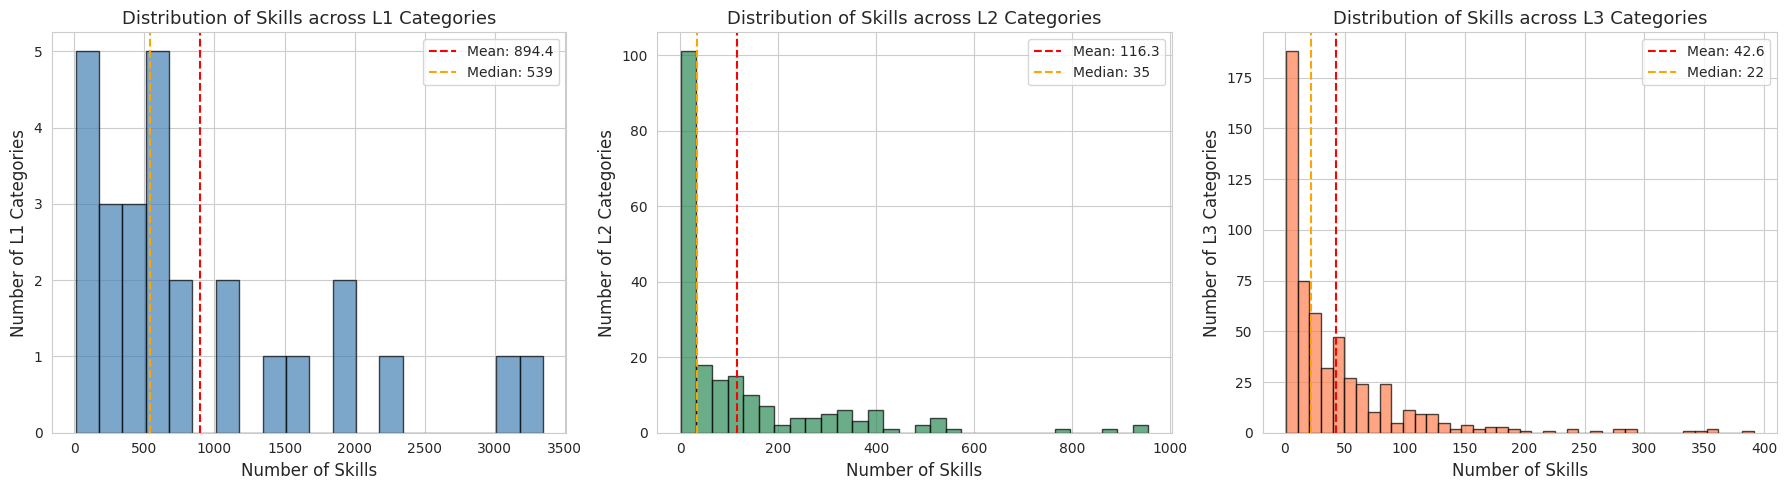

In [24]:
# Distribution of skills across L1, L2, and L3 categories
print("Distribution of skills across hierarchy levels:\n")

# L1 distribution
l1_dist = df_h.groupby('level1_label')['skillUri'].count().sort_values(ascending=False)
print(f"L1 Categories ({len(l1_dist)} categories):")
print(f"  Mean skills per category: {l1_dist.mean():.1f}")
print(f"  Median skills per category: {l1_dist.median():.0f}")
print(f"  Max skills in a category: {l1_dist.max()}")
print(f"  Min skills in a category: {l1_dist.min()}")
print(f"\nTop 5 L1 categories by skill count:")
for label, count in l1_dist.head(5).items():
    print(f"  - {label}: {count:,} skills")

# L2 distribution
l2_dist = df_h.groupby('level2_label')['skillUri'].count().sort_values(ascending=False)
print(f"\nL2 Categories ({len(l2_dist)} categories):")
print(f"  Mean skills per category: {l2_dist.mean():.1f}")
print(f"  Median skills per category: {l2_dist.median():.0f}")
print(f"  Max skills in a category: {l2_dist.max()}")
print(f"  Min skills in a category: {l2_dist.min()}")
print(f"\nTop 5 L2 categories by skill count:")
for label, count in l2_dist.head(5).items():
    print(f"  - {label}: {count:,} skills")

# L3 distribution
l3_dist = df_h[df_h['level3_label'].notna()].groupby('level3_label')['skillUri'].count().sort_values(ascending=False)
print(f"\nL3 Categories ({len(l3_dist)} categories):")
print(f"  Mean skills per category: {l3_dist.mean():.1f}")
print(f"  Median skills per category: {l3_dist.median():.0f}")
print(f"  Max skills in a category: {l3_dist.max()}")
print(f"  Min skills in a category: {l3_dist.min()}")
print(f"\nTop 5 L3 categories by skill count:")
for label, count in l3_dist.head(5).items():
    print(f"  - {label}: {count:,} skills")

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# L1 histogram
axes[0].hist(l1_dist.values, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(l1_dist.mean(), color='red', linestyle='--', label=f'Mean: {l1_dist.mean():.1f}')
axes[0].axvline(l1_dist.median(), color='orange', linestyle='--', label=f'Median: {l1_dist.median():.0f}')
axes[0].set_xlabel('Number of Skills', fontsize=12)
axes[0].set_ylabel('Number of L1 Categories', fontsize=12)
axes[0].set_title('Distribution of Skills across L1 Categories', fontsize=13)
axes[0].legend()

# L2 histogram
axes[1].hist(l2_dist.values, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(l2_dist.mean(), color='red', linestyle='--', label=f'Mean: {l2_dist.mean():.1f}')
axes[1].axvline(l2_dist.median(), color='orange', linestyle='--', label=f'Median: {l2_dist.median():.0f}')
axes[1].set_xlabel('Number of Skills', fontsize=12)
axes[1].set_ylabel('Number of L2 Categories', fontsize=12)
axes[1].set_title('Distribution of Skills across L2 Categories', fontsize=13)
axes[1].legend()

# L3 histogram
axes[2].hist(l3_dist.values, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[2].axvline(l3_dist.mean(), color='red', linestyle='--', label=f'Mean: {l3_dist.mean():.1f}')
axes[2].axvline(l3_dist.median(), color='orange', linestyle='--', label=f'Median: {l3_dist.median():.0f}')
axes[2].set_xlabel('Number of Skills', fontsize=12)
axes[2].set_ylabel('Number of L3 Categories', fontsize=12)
axes[2].set_title('Distribution of Skills across L3 Categories', fontsize=13)
axes[2].legend()

plt.tight_layout()
plt.show()


### ISCO Grouping Statistics (1-digit to 4-digit)


In [25]:
# Count ISCO groups at each digit level
isco_codes = isco_groups['code'].astype(int)

isco_1digit = len(set(isco_codes[isco_codes < 10]))
isco_2digit = len(set(isco_codes[(isco_codes < 100) & (isco_codes >= 10)]))
isco_3digit = len(set(isco_codes[(isco_codes < 1000) & (isco_codes >= 100)]))
isco_4digit = len(set(isco_codes[(isco_codes < 10000) & (isco_codes >= 1000)]))

print("ISCO Grouping Statistics:")
print(f"  1-digit (Major groups): {isco_1digit}")
print(f"  2-digit (Sub-major groups): {isco_2digit}")
print(f"  3-digit (Minor groups): {isco_3digit}")
print(f"  4-digit (Unit groups): {isco_4digit}")

# Show 1-digit groups
print("\n1-digit ISCO Major Groups:")
major_groups = isco_groups[isco_codes < 10][['code', 'preferredLabel' ,'conceptUri']]
for _, row in major_groups.iterrows():
    if row['conceptUri'] not in ['http://data.europa.eu/esco/isco/C01', 'http://data.europa.eu/esco/isco/C02', 'http://data.europa.eu/esco/isco/C03']:
        print(f"  {row['code']}: {row['preferredLabel']}")


ISCO Grouping Statistics:
  1-digit (Major groups): 10
  2-digit (Sub-major groups): 40
  3-digit (Minor groups): 130
  4-digit (Unit groups): 433

1-digit ISCO Major Groups:
  0: Armed forces occupations
  1: Managers
  2: Professionals
  3: Technicians and associate professionals
  4: Clerical support workers
  5: Service and sales workers
  6: Skilled agricultural, forestry and fishery workers
  7: Craft and related trades workers
  8: Plant and machine operators and assemblers
  9: Elementary occupations


### Skills with multiple parents (before DAG expansion)


In [26]:
# Count how many parents each concept has
parent_counts = broader_relations.groupby('conceptUri')['broaderUri'].count()

skills_with_multiple_parents = (parent_counts > 1).sum()
max_parents = parent_counts.max()

print("DAG Structure (Skills with Multiple Parents):")
print(f"  Skills with multiple parents: {skills_with_multiple_parents:,}")
print(f"  Maximum parents per skill: {max_parents}")

# Distribution of parent counts
parent_dist = parent_counts.value_counts().sort_index()
print("\nDistribution of parent counts:")
for n_parents, count in parent_dist.items():
    print(f"  {n_parents} parent(s): {count:,} skills")


DAG Structure (Skills with Multiple Parents):
  Skills with multiple parents: 4,761
  Maximum parents per skill: 9

Distribution of parent counts:
  1 parent(s): 9,814 skills
  2 parent(s): 3,607 skills
  3 parent(s): 901 skills
  4 parent(s): 201 skills
  5 parent(s): 37 skills
  6 parent(s): 8 skills
  7 parent(s): 4 skills
  8 parent(s): 1 skills
  9 parent(s): 2 skills


---
# 4.1.4 Exploratory Data Analysis


### Occupation distribution across 10 ISCO major groups (ESCO taxonomy)


Occupation Distribution Across ISCO Major Groups (ESCO Taxonomy):
  0 - Armed forces occupations: 21 (0.7%)
  1 - Managers: 350 (11.5%)
  2 - Professionals: 868 (28.6%)
  3 - Technicians and associate professionals: 646 (21.3%)
  4 - Clerical support workers: 89 (2.9%)
  5 - Service and sales workers: 204 (6.7%)
  6 - Skilled agricultural, forestry and fishery workers: 44 (1.4%)
  7 - Craft and related trades workers: 394 (13.0%)
  8 - Plant and machine operators, and assemblers: 347 (11.4%)
  9 - Elementary occupations: 76 (2.5%)


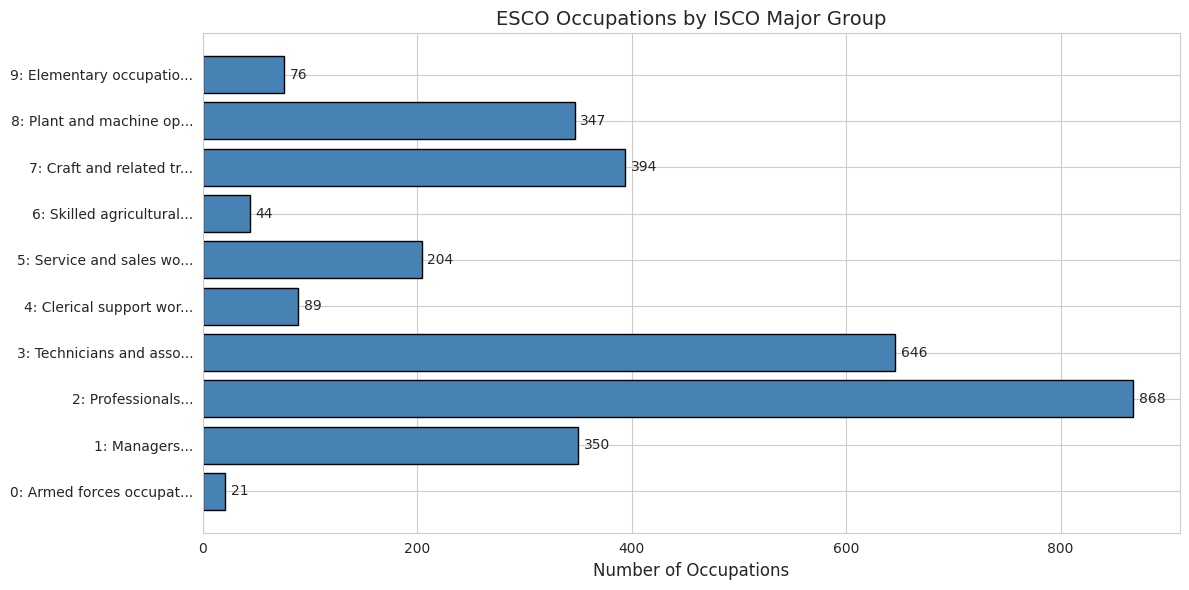

In [27]:
# ISCO major group names
isco_major_names = {
    '0': 'Armed forces occupations',
    '1': 'Managers',
    '2': 'Professionals',
    '3': 'Technicians and associate professionals',
    '4': 'Clerical support workers',
    '5': 'Service and sales workers',
    '6': 'Skilled agricultural, forestry and fishery workers',
    '7': 'Craft and related trades workers',
    '8': 'Plant and machine operators, and assemblers',
    '9': 'Elementary occupations',
}

# Create ISCO level columns
occupations_with_levels = occupations.copy()
occupations_with_levels['isco_level1'] = occupations_with_levels['code'].astype(str).str[0]
occupations_with_levels['isco_level2'] = occupations_with_levels['code'].astype(str).str[:2]
occupations_with_levels['isco_level3'] = occupations_with_levels['code'].astype(str).str[:3]
occupations_with_levels['isco_level4'] = occupations_with_levels['code'].astype(str).str[:4]

occupations_with_levels

# Count occupations per ISCO major group (from ESCO taxonomy)
isco_major_counts = occupations_with_levels['isco_level1'].value_counts().to_dict()

print("Occupation Distribution Across ISCO Major Groups (ESCO Taxonomy):")
total_occ = sum(isco_major_counts.values())
for code in sorted(isco_major_counts.keys()):
    name = isco_major_names.get(code, 'Unknown')
    count = isco_major_counts[code]
    print(f"  {code} - {name}: {count:,} ({count/total_occ*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
codes = sorted(isco_major_counts.keys())
counts = [isco_major_counts[c] for c in codes]
labels = [f"{c}: {isco_major_names.get(c, 'Unknown')[:20]}..." for c in codes]
ax.barh(labels, counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Occupations', fontsize=12)
ax.set_title('ESCO Occupations by ISCO Major Group', fontsize=14)
for i, v in enumerate(counts):
    ax.text(v + 5, i, str(v), va='center')
plt.tight_layout()
plt.show()

### ISCO distribution in DECORTE dataset (job experiences)


ISCO Distribution in DECORTE Dataset (Job Experiences):
  0 - Armed forces occupations: 42 (0.4%)
  1 - Managers: 2,405 (24.3%)
  2 - Professionals: 3,138 (31.6%)
  3 - Technicians and associate professionals: 2,037 (20.5%)
  4 - Clerical support workers: 859 (8.7%)
  5 - Service and sales workers: 938 (9.5%)
  6 - Skilled agricultural, forestry and fishery workers: 12 (0.1%)
  7 - Craft and related trades workers: 239 (2.4%)
  8 - Plant and machine operators, and assemblers: 68 (0.7%)
  9 - Elementary occupations: 179 (1.8%)


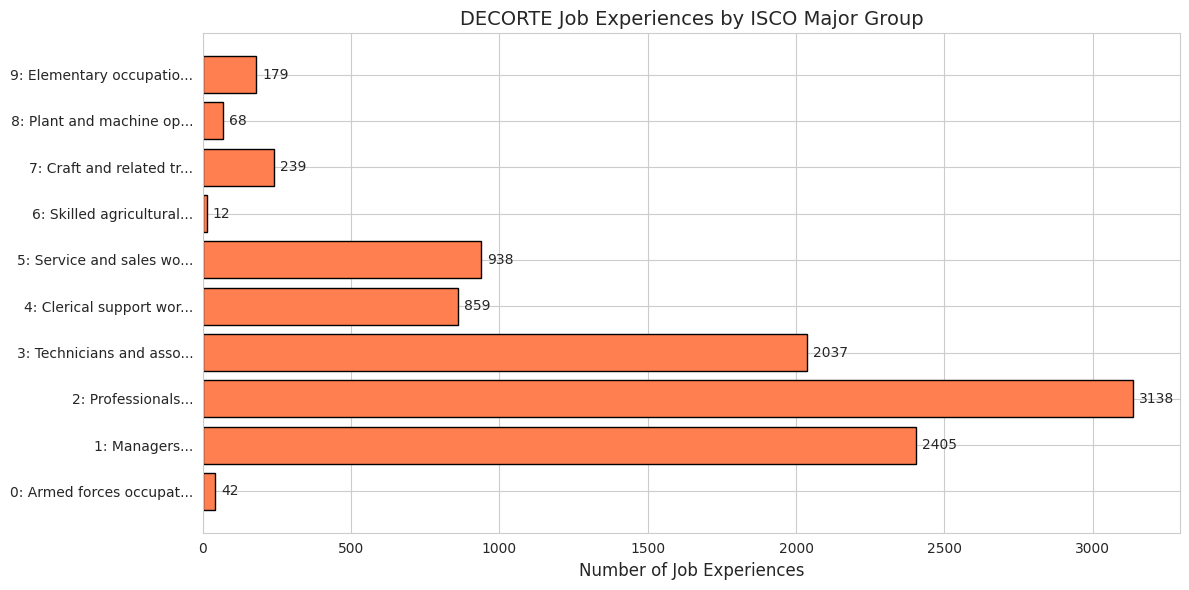

In [28]:
# Create ISCO code lookup from occupations_with_levels
occ_to_isco_major = {}
for _, row in occupations_with_levels.iterrows():
    uri = row['conceptUri']
    isco_major = str(row['isco_level1']) if pd.notna(row['isco_level1']) else None
    if uri and isco_major:
        occ_to_isco_major[uri] = isco_major

# Count ISCO groups in DECORTE dataset
decorte_isco_counts = Counter()
for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        n_exp = example['number_of_experiences']
        for i in range(n_exp):
            uri = example.get(f'ESCO_uri_{i}')
            if uri and uri in occ_to_isco_major:
                major_group = occ_to_isco_major[uri]
                decorte_isco_counts[major_group] += 1

print("ISCO Distribution in DECORTE Dataset (Job Experiences):")
total_decorte = sum(decorte_isco_counts.values())
for code in sorted(decorte_isco_counts.keys()):
    name = isco_major_names.get(code, 'Unknown')
    count = decorte_isco_counts[code]
    print(f"  {code} - {name}: {count:,} ({count/total_decorte*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
codes = sorted(decorte_isco_counts.keys())
counts = [decorte_isco_counts[c] for c in codes]
labels = [f"{c}: {isco_major_names.get(c, 'Unknown')[:20]}..." for c in codes]
ax.barh(labels, counts, color='coral', edgecolor='black')
ax.set_xlabel('Number of Job Experiences', fontsize=12)
ax.set_title('DECORTE Job Experiences by ISCO Major Group', fontsize=14)
for i, v in enumerate(counts):
    ax.text(v + 20, i, str(v), va='center')
plt.tight_layout()
plt.show()


In [29]:
decorte_dataset

DatasetDict({
    train: Dataset({
        features: ['identifier', 'industry', 'number_of_experiences', 'uuid_0', 'title_0', 'description_0', 'start_0', 'end_0', 'ESCO_uri_0', 'ESCO_title_0', 'uuid_1', 'title_1', 'description_1', 'start_1', 'end_1', 'ESCO_uri_1', 'ESCO_title_1', 'uuid_2', 'title_2', 'description_2', 'start_2', 'end_2', 'ESCO_uri_2', 'ESCO_title_2', 'uuid_3', 'title_3', 'description_3', 'start_3', 'end_3', 'ESCO_uri_3', 'ESCO_title_3', 'uuid_4', 'title_4', 'description_4', 'start_4', 'end_4', 'ESCO_uri_4', 'ESCO_title_4', 'uuid_5', 'title_5', 'description_5', 'start_5', 'end_5', 'ESCO_uri_5', 'ESCO_title_5', 'uuid_6', 'title_6', 'description_6', 'start_6', 'end_6', 'ESCO_uri_6', 'ESCO_title_6', 'uuid_7', 'title_7', 'description_7', 'start_7', 'end_7', 'ESCO_uri_7', 'ESCO_title_7', 'uuid_8', 'title_8', 'description_8', 'start_8', 'end_8', 'ESCO_uri_8', 'ESCO_title_8', 'uuid_9', 'title_9', 'description_9', 'start_9', 'end_9', 'ESCO_uri_9', 'ESCO_title_9', 'uuid_10', 'tit

### Career length distribution (percentiles)


Career Length Percentiles:
  10th percentile: 3.0 jobs
  25th percentile: 3.0 jobs
  50th percentile: 4.0 jobs
  75th percentile: 5.0 jobs
  90th percentile: 7.0 jobs
  95th percentile: 8.0 jobs
  99th percentile: 11.0 jobs


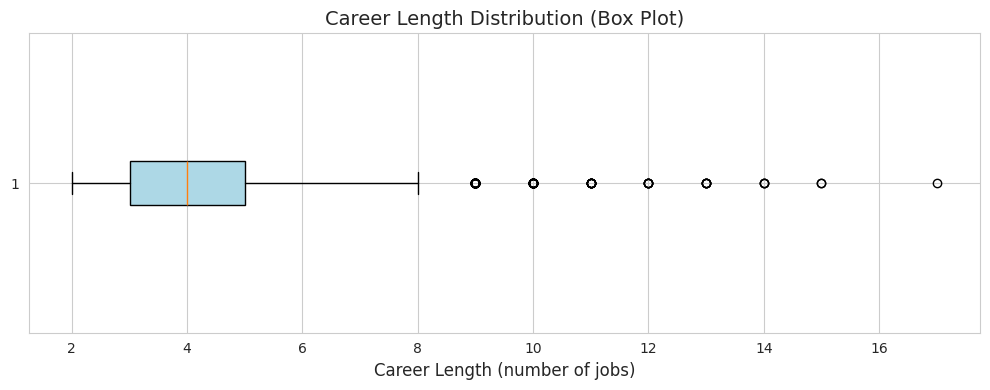

In [30]:
percentiles = [10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(all_career_lengths, percentiles)

print("Career Length Percentiles:")
for p, v in zip(percentiles, percentile_values):
    print(f"  {p}th percentile: {v:.1f} jobs")

# Box plot
fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(all_career_lengths, vert=False, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax.set_xlabel('Career Length (number of jobs)', fontsize=12)
ax.set_title('Career Length Distribution (Box Plot)', fontsize=14)
plt.tight_layout()
plt.show()


### Transition patterns: % within same ISCO group vs across groups


In [32]:
# Build occ_to_isco mapping from ESCO occupations
occ_to_isco = {}
for _, row in occupations.iterrows():
    uri = row['conceptUri']
    isco_code = row.get('iscoGroup', '')
    if uri and isco_code:
        occ_to_isco[uri] = str(isco_code)


Transition Patterns:
  Total job transitions analyzed: 7,753
  Transitions within same ISCO major group: 3,592 (46.3%)
  Transitions across ISCO major groups: 4,161 (53.7%)


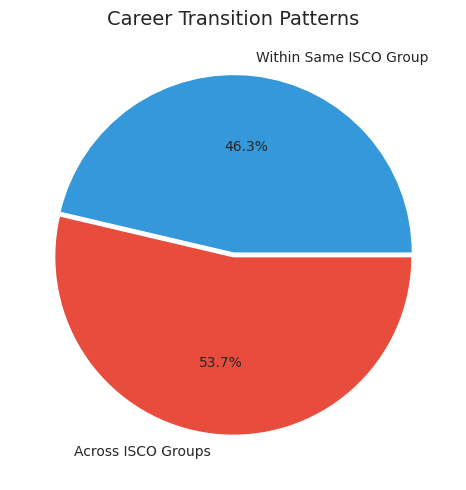

In [33]:
same_isco_transitions = 0
cross_isco_transitions = 0
total_transitions = 0

for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        n_exp = example['number_of_experiences']
        if n_exp < 2:
            continue
            
        prev_major = None
        for i in range(n_exp):
            uri = example.get(f'ESCO_uri_{i}')
            if uri and uri in occ_to_isco:
                isco = occ_to_isco[uri]
                if len(isco) >= 1:
                    curr_major = isco[0]
                    if prev_major is not None:
                        total_transitions += 1
                        if curr_major == prev_major:
                            same_isco_transitions += 1
                        else:
                            cross_isco_transitions += 1
                    prev_major = curr_major

pct_same = same_isco_transitions / total_transitions * 100 if total_transitions > 0 else 0
pct_cross = cross_isco_transitions / total_transitions * 100 if total_transitions > 0 else 0

print("Transition Patterns:")
print(f"  Total job transitions analyzed: {total_transitions:,}")
print(f"  Transitions within same ISCO major group: {same_isco_transitions:,} ({pct_same:.1f}%)")
print(f"  Transitions across ISCO major groups: {cross_isco_transitions:,} ({pct_cross:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
ax.pie([same_isco_transitions, cross_isco_transitions], 
       labels=['Within Same ISCO Group', 'Across ISCO Groups'],
       autopct='%1.1f%%',
       colors=['#3498db', '#e74c3c'],
       explode=(0.02, 0))
ax.set_title('Career Transition Patterns', fontsize=14)
plt.tight_layout()
plt.show()


### Transition matrix between ISCO major groups


In [49]:
occupations_with_levels

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level1,isco_level2,isco_level3,isco_level4
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2024-01-25T11:28:50.295Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,metal drawing machine technician\nmetal drawin...,NaN,released,2024-01-23T10:09:32.099Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,8,81,812,8121
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,inspector of precision instruments\nprecision ...,NaN,released,2024-01-25T15:00:12.188Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Precision device inspectors make sure precisio...,7543.10.3,7,75,754,7543
3,Occupation,http://data.europa.eu/esco/occupation/0022f466...,3155,air traffic safety technician,air traffic safety electronics hardware specia...,NaN,released,2024-01-29T16:01:13.998Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Air traffic safety technicians provide technic...,3155.1,3,31,315,3155
4,Occupation,http://data.europa.eu/esco/occupation/002da35b...,2431,hospitality revenue manager,hospitality revenues manager\nyield manager\nh...,NaN,released,2024-01-11T10:28:45.871Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Hospitality revenue managers maximise revenue ...,2431.9,2,24,243,2431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3034,Occupation,http://data.europa.eu/esco/occupation/ff656b3a...,2120,demographer,demography research analyst\ndemography studie...,NaN,released,2024-01-23T10:55:28.923Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/8ae4...,Demographers study a variety of parameters rel...,2120.2,2,21,212,2120
3035,Occupation,http://data.europa.eu/esco/occupation/ff8d4065...,9612,sorter labourer,sorter laborer\ngrader\nyard labourer\nrecycle...,NaN,released,2024-01-16T11:18:17.704Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Sorter labourers sort recyclable materials and...,9612.2,9,96,961,9612
3036,Occupation,http://data.europa.eu/esco/occupation/ffa4dd5d...,5414,armoured car guard,armoured truck escort\ntruck escort\narmored c...,NaN,released,2022-01-13T09:51:50.643Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Armoured car guards ensure the safe transporta...,5414.1.2,5,54,541,5414
3037,Occupation,http://data.europa.eu/esco/occupation/ffade2f4...,2422,civil service administrative officer,government administrative officer\nlocal autho...,NaN,released,2024-01-16T14:38:39.909Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Civil service administrative officers perform ...,2422.1,2,24,242,2422


In [50]:
occ_to_isco

{'http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34': '2654',
 'http://data.europa.eu/esco/occupation/000e93a3-d956-4e45-aacb-f12c83fedf84': '8121',
 'http://data.europa.eu/esco/occupation/0019b951-c699-4191-8208-9822882d150c': '7543',
 'http://data.europa.eu/esco/occupation/0022f466-426c-41a4-ac96-a235c945cf97': '3155',
 'http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f': '2431',
 'http://data.europa.eu/esco/occupation/0044c991-c26f-4261-a213-4bd1c0564a4c': '3212',
 'http://data.europa.eu/esco/occupation/00634fc4-802a-461b-8af0-499273756f99': '3116',
 'http://data.europa.eu/esco/occupation/00674f21-2f8f-4a41-9896-133f7cbe2a6e': '5312',
 'http://data.europa.eu/esco/occupation/006cc1f9-2841-41c3-991a-dc3f2f3bd533': '2264',
 'http://data.europa.eu/esco/occupation/00747307-6341-4266-a061-25416f7c6a96': '2310',
 'http://data.europa.eu/esco/occupation/0085f271-5999-4d42-b879-75c3b4269883': '8160',
 'http://data.europa.eu/esco/occupation/009

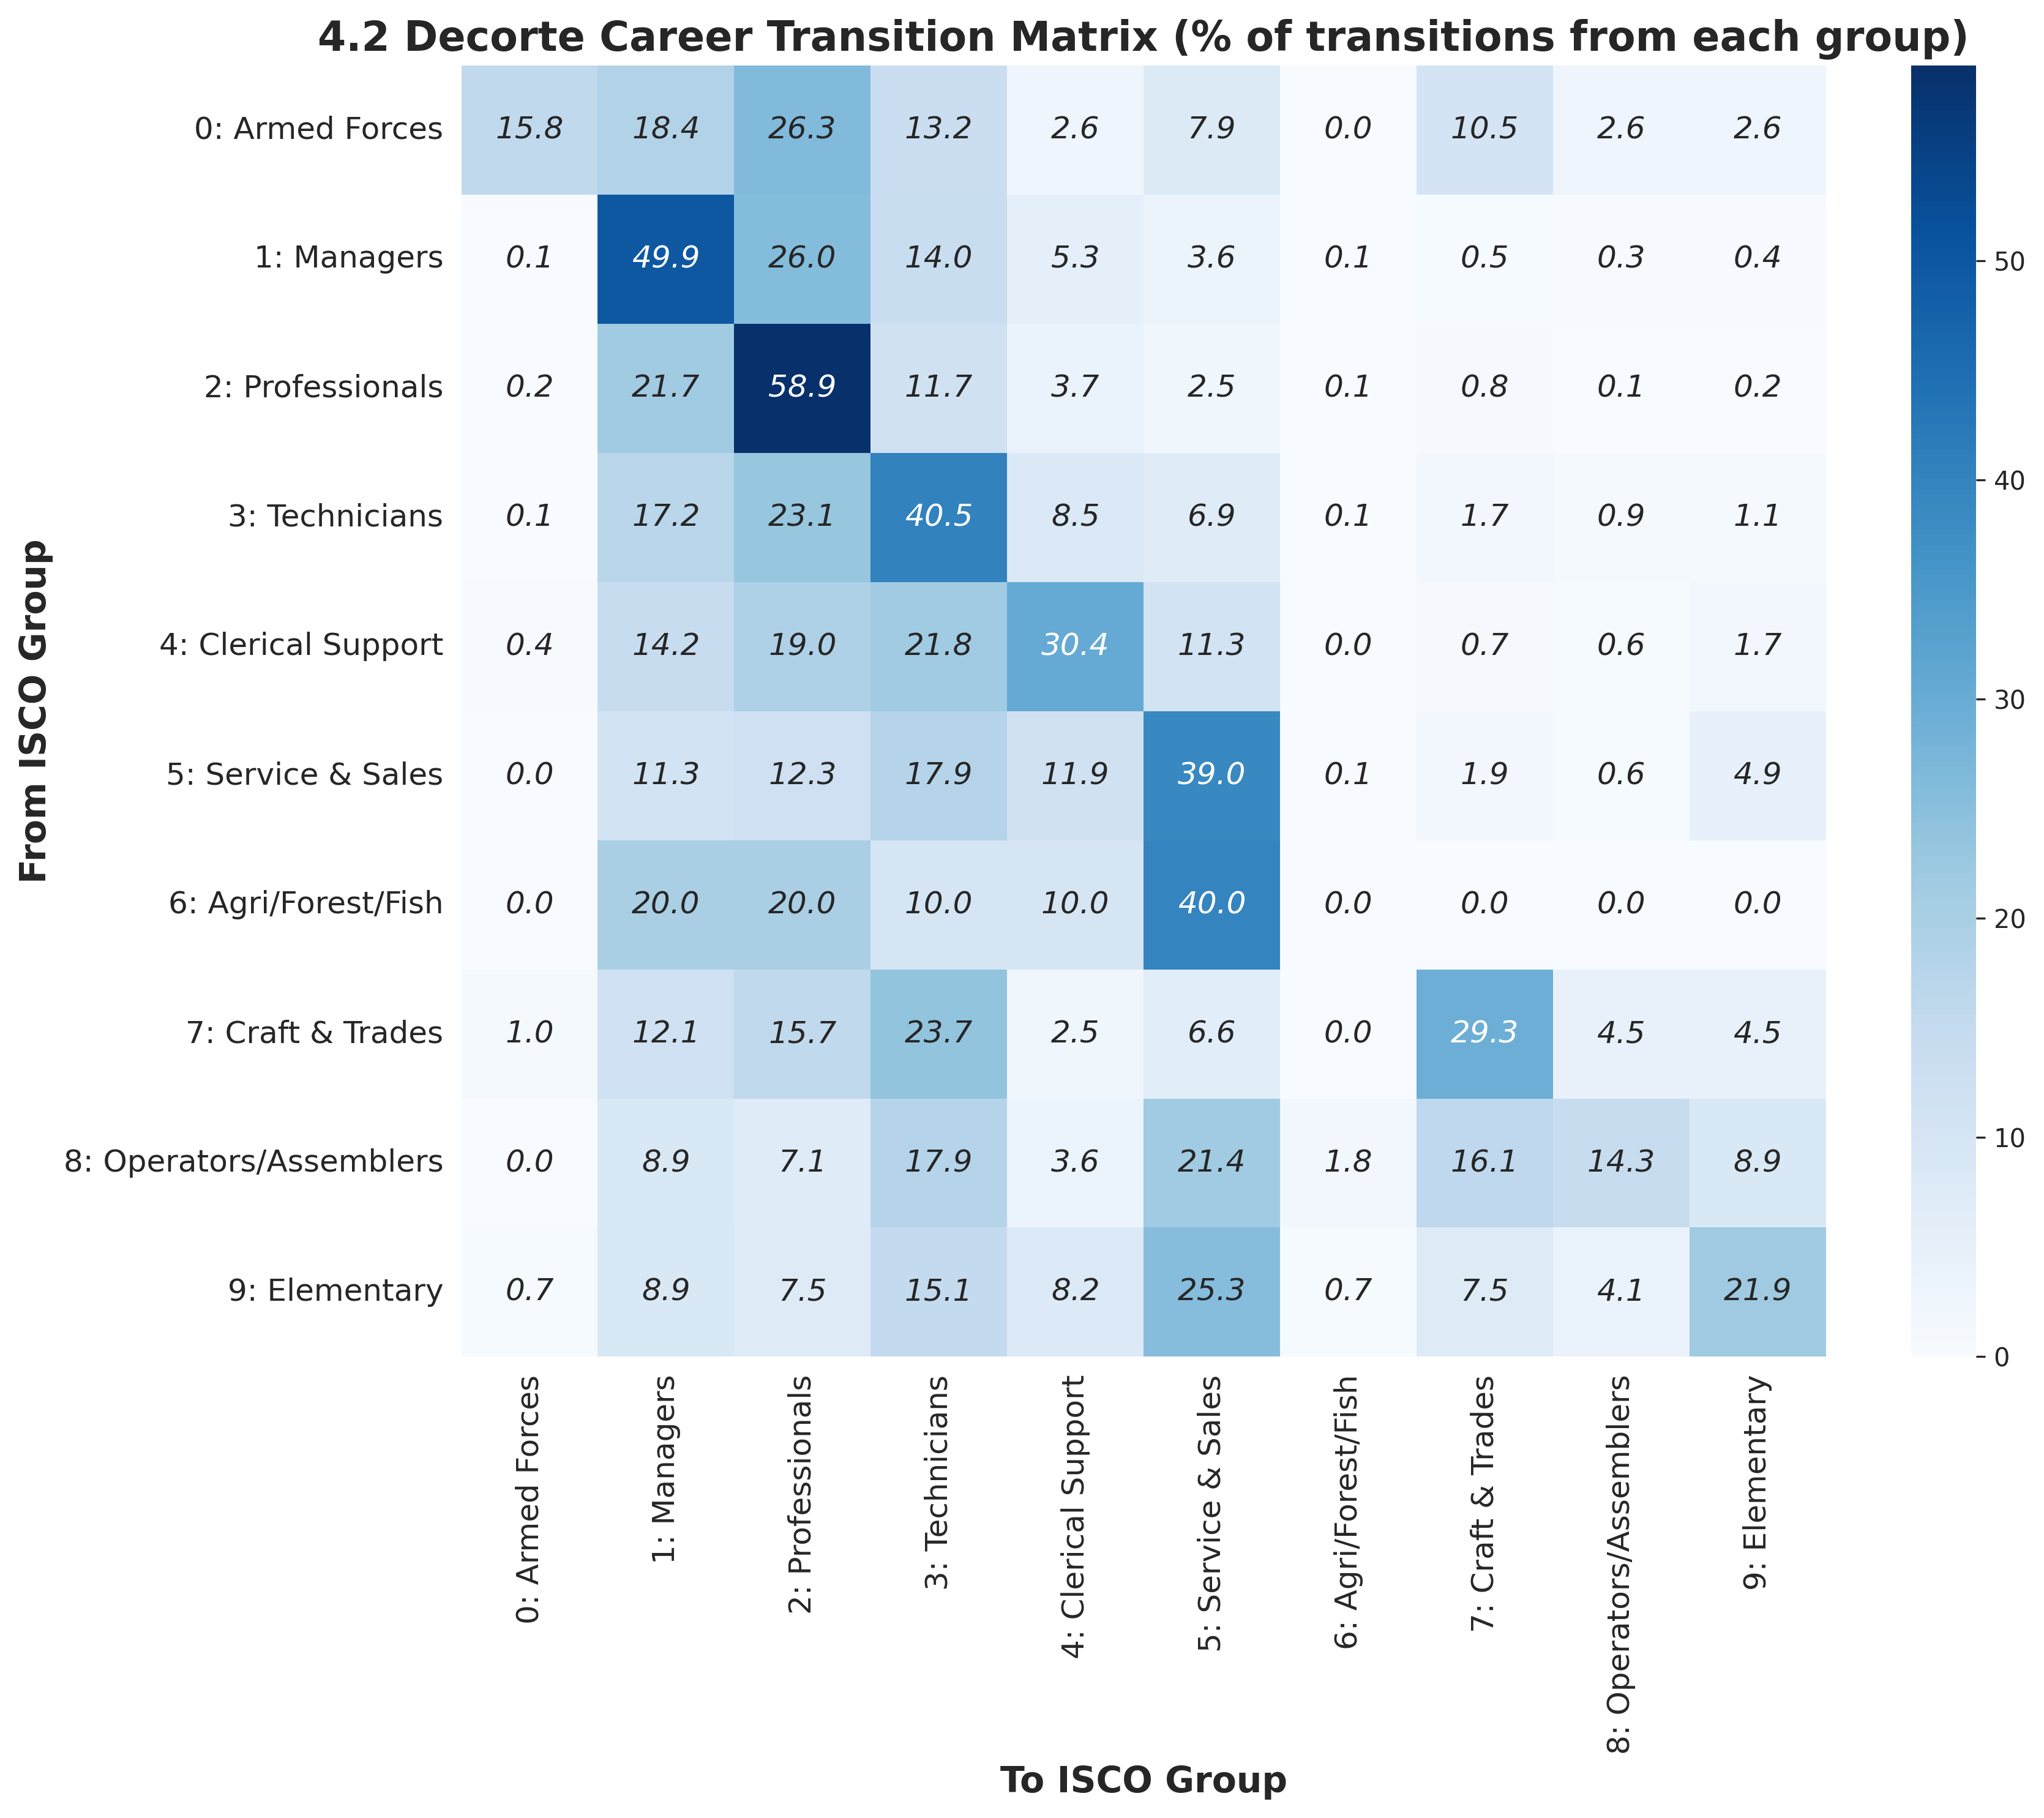

In [ ]:
# Build transition matrix
transition_matrix = Counter()
#occupations_with_levels.set_index('conceptUri', inplace=True)

for split_name in ['train', 'validation', 'test']:
    for example in decorte_dataset[split_name]:
        n_exp = example['number_of_experiences']
        if n_exp < 2:
            continue
            
        prev_major = None
        for i in range(n_exp):
            uri = example.get(f'ESCO_uri_{i}')
            if uri and uri in occupations_with_levels.index:
                curr_major = occupations_with_levels.loc[uri, 'isco_level1']
                if prev_major is not None:
                    transition_matrix[(prev_major, curr_major)] += 1
                prev_major = curr_major

# Convert to DataFrame
isco_codes_present = sorted(set([t[0] for t in transition_matrix.keys()] + [t[1] for t in transition_matrix.keys()]))
matrix_df = pd.DataFrame(0, index=isco_codes_present, columns=isco_codes_present)
for (from_code, to_code), count in transition_matrix.items():
    matrix_df.loc[from_code, to_code] = count

# Create a mapping for cleaner, shorter labels
isco_short_names = {
    '0': 'Armed Forces',
    '1': 'Managers',
    '2': 'Professionals',
    '3': 'Technicians',
    '4': 'Clerical Support',
    '5': 'Service & Sales',
    '6': 'Agri/Forest/Fish',
    '7': 'Craft & Trades',
    '8': 'Operators/Assemblers',
    '9': 'Elementary'
}

# Use these in the heatmap
xticklabels=[f"{c}: {isco_short_names.get(c, '')}" for c in isco_codes_present]
yticklabels=[f"{c}: {isco_short_names.get(c, '')}" for c in isco_codes_present]

# Normalize by row
matrix_normalized = matrix_df.div(matrix_df.sum(axis=1), axis=0) * 100

# Visualize
fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
sns.heatmap(matrix_normalized, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            xticklabels=xticklabels,
            yticklabels=yticklabels,
            annot_kws={'fontsize': 12, 'fontstyle': 'italic'})
ax.set_xlabel('To ISCO Group', fontsize=14, fontweight='bold')
ax.set_ylabel('From ISCO Group', fontsize=14, fontweight='bold')
ax.set_title('4.2 Decorte Career Transition Matrix (% of transitions from each group)', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig('career_transition_matrix.pdf', dpi=300, bbox_inches='tight')
plt.savefig('career_transition_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [36]:
isco_major_names

{'0': 'Armed forces occupations',
 '1': 'Managers',
 '2': 'Professionals',
 '3': 'Technicians and associate professionals',
 '4': 'Clerical support workers',
 '5': 'Service and sales workers',
 '6': 'Skilled agricultural, forestry and fishery workers',
 '7': 'Craft and related trades workers',
 '8': 'Plant and machine operators, and assemblers',
 '9': 'Elementary occupations'}

In [37]:
matrix_normalized.rename(index=isco_major_names, columns=isco_major_names).round(2)

,Managers,Professionals,Technicians and associate professionals,Clerical support workers,Service and sales workers,"Skilled agricultural, forestry and fishery workers",Craft and related trades workers,"Plant and machine operators, and assemblers",Elementary occupations
Managers,49.76,25.96,14.09,5.28,3.64,0.05,0.53,0.26,0.42
Professionals,21.88,58.86,11.77,3.68,2.48,0.13,0.86,0.13,0.21
Technicians and associate professionals,17.19,23.14,40.45,8.41,6.94,0.06,1.78,0.98,1.04
Clerical support workers,14.49,18.99,21.94,30.38,11.25,0.00,0.70,0.56,1.69
Service and sales workers,11.27,12.31,17.88,11.92,38.99,0.13,1.94,0.65,4.92
"Skilled agricultural, forestry and fishery workers",20.00,20.00,10.00,10.00,40.00,0.00,0.00,0.00,0.00
Craft and related trades workers,13.13,15.66,23.74,2.53,6.57,0.00,29.29,4.55,4.55
"Plant and machine operators, and assemblers",8.93,7.14,17.86,3.57,21.43,1.79,16.07,14.29,8.93
Elementary occupations,8.90,7.53,15.75,8.22,25.34,0.68,7.53,4.11,21.92


In [38]:
isco_major_names

{'0': 'Armed forces occupations',
 '1': 'Managers',
 '2': 'Professionals',
 '3': 'Technicians and associate professionals',
 '4': 'Clerical support workers',
 '5': 'Service and sales workers',
 '6': 'Skilled agricultural, forestry and fishery workers',
 '7': 'Craft and related trades workers',
 '8': 'Plant and machine operators, and assemblers',
 '9': 'Elementary occupations'}

---
## Summary Statistics


In [39]:
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\n📊 DECORTE Dataset:")
print(f"   • Total career histories: {total_careers:,}")
print(f"   • Total job experiences: {unique_exp:,}")
print(f"   • Average career length: {avg_career_length:.2f} jobs")
print(f"   • Unique ESCO occupations: {len(all_esco_uris):,}")

print("\n📚 ESCO Taxonomy:")
print(f"   • Total occupations: {total_occupations:,}")
print(f"   • Total skills (mapped to an occupation): {occ_skill_relations.skillUri.nunique():,}")
print(f"   • Occupation-skill relations: {total_relations:,}")
print(f"   • Essential relations: {essential_relations:,} ({essential_relations/total_relations*100:.1f}%)")
print(f"   • Average skills per occupation: {skills_per_occ.mean():.1f}")

print("\n🔄 Career Transitions:")
print(f"   • Within same ISCO group: {pct_same:.1f}%")
print(f"   • Across ISCO groups: {pct_cross:.1f}%")

print("\n" + "="*60)


SUMMARY STATISTICS

📊 DECORTE Dataset:
   • Total career histories: 2,164
   • Total job experiences: 9,885
   • Average career length: 4.58 jobs
   • Unique ESCO occupations: 1,155

📚 ESCO Taxonomy:
   • Total occupations: 3,039
   • Total skills (mapped to an occupation): 13,492
   • Occupation-skill relations: 129,004
   • Essential relations: 67,622 (52.4%)
   • Average skills per occupation: 42.4

🔄 Career Transitions:
   • Within same ISCO group: 46.3%
   • Across ISCO groups: 53.7%



In [40]:
df_h.columns

Index(['skillUri', 'skillLabel', 'skillType', 'skillAltLabels', 'reuseLevel',
       'status', 'description', 'definition', 'pillar_uri', 'pillar_label',
       'parent_uri', 'parent_label', 'full_path_uris', 'full_path_labels',
       'level1_uri', 'level1_label', 'level2_uri', 'level2_label',
       'level3_uri', 'level3_label'],
      dtype='object')

In [41]:
df_h.pivot_table(
    index='level1_label',
    columns='pillar_label',
    values='skillUri',
    aggfunc='nunique'
)

pillar_label,knowledge,language skills and knowledge,skills,transversal skills and competences
level1_label,,,,
"agriculture, forestry, fisheries and veterinary",133.0,NaN,NaN,NaN
arts and humanities,281.0,NaN,NaN,NaN
assisting and caring,NaN,NaN,1276.0,NaN
"business, administration and law",491.0,NaN,NaN,NaN
classical languages,NaN,9.0,NaN,NaN
"communication, collaboration and creativity",NaN,NaN,2691.0,NaN
constructing,NaN,NaN,587.0,NaN
core skills and competences,NaN,NaN,NaN,529.0
education,41.0,NaN,NaN,NaN


In [42]:
decorte_dataset

DatasetDict({
    train: Dataset({
        features: ['identifier', 'industry', 'number_of_experiences', 'uuid_0', 'title_0', 'description_0', 'start_0', 'end_0', 'ESCO_uri_0', 'ESCO_title_0', 'uuid_1', 'title_1', 'description_1', 'start_1', 'end_1', 'ESCO_uri_1', 'ESCO_title_1', 'uuid_2', 'title_2', 'description_2', 'start_2', 'end_2', 'ESCO_uri_2', 'ESCO_title_2', 'uuid_3', 'title_3', 'description_3', 'start_3', 'end_3', 'ESCO_uri_3', 'ESCO_title_3', 'uuid_4', 'title_4', 'description_4', 'start_4', 'end_4', 'ESCO_uri_4', 'ESCO_title_4', 'uuid_5', 'title_5', 'description_5', 'start_5', 'end_5', 'ESCO_uri_5', 'ESCO_title_5', 'uuid_6', 'title_6', 'description_6', 'start_6', 'end_6', 'ESCO_uri_6', 'ESCO_title_6', 'uuid_7', 'title_7', 'description_7', 'start_7', 'end_7', 'ESCO_uri_7', 'ESCO_title_7', 'uuid_8', 'title_8', 'description_8', 'start_8', 'end_8', 'ESCO_uri_8', 'ESCO_title_8', 'uuid_9', 'title_9', 'description_9', 'start_9', 'end_9', 'ESCO_uri_9', 'ESCO_title_9', 'uuid_10', 'tit

In [43]:
# ESCO label frequency distribution in DECORTE
esco_label_counts = pd.DataFrame(
    all_title_description_pairs, 
    columns=['raw_title', 'raw_description', 'esco_uri', 'split']).merge(
        occupations, how='left', left_on='esco_uri', right_on='conceptUri'
    ).groupby(['preferredLabel']).split.count().sort_values()

# Create frequency bins
frequency_bins = [
    (1, 1, '1×'),
    (2, 5, '2-5×'),
    (6, 10, '6-10×'),
    (11, 20, '11-20×'),
    (21, 50, '21-50×'),
    (51, float('inf'), '51+×')
]

print("\n" + "="*60)
print("ESCO LABEL FREQUENCY DISTRIBUTION IN DECORTE")
print("="*60)

for min_freq, max_freq, label in frequency_bins:
    count = ((esco_label_counts >= min_freq) & (esco_label_counts <= max_freq)).sum()
    pct = count / len(esco_label_counts) * 100
    print(f"   • {label}: {count:,} labels ({pct:.1f}%)")

print(f"\nTotal unique ESCO labels: {len(esco_label_counts):,}")
print("="*60)


ESCO LABEL FREQUENCY DISTRIBUTION IN DECORTE
   • 1×: 381 labels (33.0%)
   • 2-5×: 425 labels (36.8%)
   • 6-10×: 148 labels (12.8%)
   • 11-20×: 95 labels (8.2%)
   • 21-50×: 63 labels (5.5%)
   • 51+×: 42 labels (3.6%)

Total unique ESCO labels: 1,154


In [55]:
# Create ISCO level columns
occupations_with_levels = occupations.copy()
occupations_with_levels['isco_level1'] = occupations_with_levels['code'].astype(str).str[0]
occupations_with_levels['isco_level2'] = occupations_with_levels['code'].astype(str).str[:2]
occupations_with_levels['isco_level3'] = occupations_with_levels['code'].astype(str).str[:3]
occupations_with_levels['isco_level4'] = occupations_with_levels['code'].astype(str).str[:4]

occupations_with_levels

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level1,isco_level2,isco_level3,isco_level4
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2024-01-25T11:28:50.295Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,metal drawing machine technician\nmetal drawin...,NaN,released,2024-01-23T10:09:32.099Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,8,81,812,8121
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,inspector of precision instruments\nprecision ...,NaN,released,2024-01-25T15:00:12.188Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Precision device inspectors make sure precisio...,7543.10.3,7,75,754,7543
3,Occupation,http://data.europa.eu/esco/occupation/0022f466...,3155,air traffic safety technician,air traffic safety electronics hardware specia...,NaN,released,2024-01-29T16:01:13.998Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Air traffic safety technicians provide technic...,3155.1,3,31,315,3155
4,Occupation,http://data.europa.eu/esco/occupation/002da35b...,2431,hospitality revenue manager,hospitality revenues manager\nyield manager\nh...,NaN,released,2024-01-11T10:28:45.871Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Hospitality revenue managers maximise revenue ...,2431.9,2,24,243,2431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3034,Occupation,http://data.europa.eu/esco/occupation/ff656b3a...,2120,demographer,demography research analyst\ndemography studie...,NaN,released,2024-01-23T10:55:28.923Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/8ae4...,Demographers study a variety of parameters rel...,2120.2,2,21,212,2120
3035,Occupation,http://data.europa.eu/esco/occupation/ff8d4065...,9612,sorter labourer,sorter laborer\ngrader\nyard labourer\nrecycle...,NaN,released,2024-01-16T11:18:17.704Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Sorter labourers sort recyclable materials and...,9612.2,9,96,961,9612
3036,Occupation,http://data.europa.eu/esco/occupation/ffa4dd5d...,5414,armoured car guard,armoured truck escort\ntruck escort\narmored c...,NaN,released,2022-01-13T09:51:50.643Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Armoured car guards ensure the safe transporta...,5414.1.2,5,54,541,5414
3037,Occupation,http://data.europa.eu/esco/occupation/ffade2f4...,2422,civil service administrative officer,government administrative officer\nlocal autho...,NaN,released,2024-01-16T14:38:39.909Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Civil service administrative officers perform ...,2422.1,2,24,242,2422


In [56]:
pd.DataFrame(
    all_title_description_pairs, 
    columns=['raw_title', 'raw_description', 'esco_uri', 'split']).merge(
        occupations_with_levels, how='left', left_on='esco_uri', right_on='conceptUri'
    ).query('isco_level1 == "0"')

,raw_title,raw_description,esco_uri,split,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,...,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level1,isco_level2,isco_level3,isco_level4
105,Security Police/E4 Senior Airman,"Commanded operations post, including personnel...",http://data.europa.eu/esco/occupation/c6a26e11...,train,Occupation,http://data.europa.eu/esco/occupation/c6a26e11...,110.0,armed forces officer,major\nlieutenant general\nRoal Air Force offi...,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Armed forces officers supervise operations and...,0110.2,0,01,011,0110
149,Master Sergeant,- Provided guidance and instruction to enhance...,http://data.europa.eu/esco/occupation/c6a26e11...,train,Occupation,http://data.europa.eu/esco/occupation/c6a26e11...,110.0,armed forces officer,major\nlieutenant general\nRoal Air Force offi...,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Armed forces officers supervise operations and...,0110.2,0,01,011,0110
150,Senior Instructor and Course Manager,"- Managed the health, welfare, morale, trainin...",http://data.europa.eu/esco/occupation/e4c915ff...,train,Occupation,http://data.europa.eu/esco/occupation/e4c915ff...,110.0,army major,battalion commandant\narmy commandant\narmed f...,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Army majors command large units of officers an...,0110.5,0,01,011,0110
864,Non-Commissioned Officer,"Provided leadership, training, and supervision...",http://data.europa.eu/esco/occupation/cb3b2662...,train,Occupation,http://data.europa.eu/esco/occupation/cb3b2662...,210.0,sergeant,station sergeant\ndrill sergeant\npolice sarge...,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Sergeants command squads as a second in comman...,0210.2,0,02,021,0210
882,Tank Platoon Sergeant,- Led a platoon of 70 soldiers during peacekee...,http://data.europa.eu/esco/occupation/b223f402...,train,Occupation,http://data.europa.eu/esco/occupation/b223f402...,110.0,lieutenant,police lieutenant\narmed forces lieutenant,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Lieutenants command troops of platoons of sold...,0110.10,0,01,011,0110
883,Senior Technical Support Specialist,- Pioneered the development of the first integ...,http://data.europa.eu/esco/occupation/555235ce...,train,Occupation,http://data.europa.eu/esco/occupation/555235ce...,310.0,military engineer,defence technology engineering adviser\nballis...,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Military engineers perform technical and scien...,0310.5,0,03,031,0310
884,Engineering Specialist,"- Orchestrated a 1.5-year test program, implem...",http://data.europa.eu/esco/occupation/555235ce...,train,Occupation,http://data.europa.eu/esco/occupation/555235ce...,310.0,military engineer,defence technology engineering adviser\nballis...,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Military engineers perform technical and scien...,0310.5,0,03,031,0310
986,Operations Specialist,Operated radar and communications equipment as...,http://data.europa.eu/esco/occupation/262f21a3...,train,Occupation,http://data.europa.eu/esco/occupation/262f21a3...,110.0,navy officer,sub-lieutenant\nship-of-the-line ensign\nmidsh...,NaN,...,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Navy officers command missions during conflict...,0110.11,0,01,011,0110
1503,Commanding Officer,Commanded a 143 man Military Police organizati...,http://data.europa.eu/esco/occupation/c

In [3]:
from typing import Optional

def clean_isco_code(code: str) -> Optional[str]:
    """Normalize ISCO code to a 4-digit string; returns None if invalid."""
    if code is None or str(code).lower() == "nan":
        return None
    s = str(code).strip()
    # Remove trailing .0 if coming from float CSV
    if s.endswith(".0"):
        s = s[:-2]
    # Keep only digits
    s = "".join(ch for ch in s if ch.isdigit())
    if not s:
        return None
    return s.zfill(4)[:4]

In [4]:
clean_isco_code('110.0')

'0110'

In [57]:
occupations_with_levels.isco_level1.value_counts()

isco_level1
2    868
3    646
7    394
1    350
8    347
5    204
4     89
9     76
6     44
0     21
Name: count, dtype: int64

In [58]:
# ESCO Label Distribution in DECORTE Dataset
print("\n" + "="*60)
print("ESCO LABEL DISTRIBUTION IN DECORTE DATASET")
print("="*60)

# Get all skills from DECORTE career histories
decorte_skills = set()
for skills_list in df_decorte['skills']:
    if isinstance(skills_list, list):
        decorte_skills.update(skills_list)

print(f"\nTotal unique skills in DECORTE: {len(decorte_skills):,}")

# Merge with ESCO hierarchy to get labels
decorte_skill_labels = df_h[df_h['skillUri'].isin(decorte_skills)].copy()

print(f"\nSkills matched to ESCO hierarchy: {len(decorte_skill_labels):,}")

# Distribution by pillar
print("\n📊 Distribution by Pillar:")
pillar_dist = decorte_skill_labels['pillar_label'].value_counts()
for pillar, count in pillar_dist.items():
    pct = count / len(decorte_skill_labels) * 100
    print(f"   • {pillar}: {count:,} ({pct:.1f}%)")

# Distribution by skill type
print("\n📊 Distribution by Skill Type:")
type_dist = decorte_skill_labels['skillType'].value_counts()
for skill_type, count in type_dist.items():
    pct = count / len(decorte_skill_labels) * 100
    print(f"   • {skill_type}: {count:,} ({pct:.1f}%)")

# Top level 1 categories
print("\n📊 Top 10 Level 1 Categories:")
level1_dist = decorte_skill_labels['level1_label'].value_counts().head(10)
for category, count in level1_dist.items():
    pct = count / len(decorte_skill_labels) * 100
    print(f"   • {category}: {count:,} ({pct:.1f}%)")

print("\n" + "="*60)



ESCO LABEL DISTRIBUTION IN DECORTE DATASET


KeyError: 'skills'


FIGURE 4.1: DATASET CHARACTERISTICS


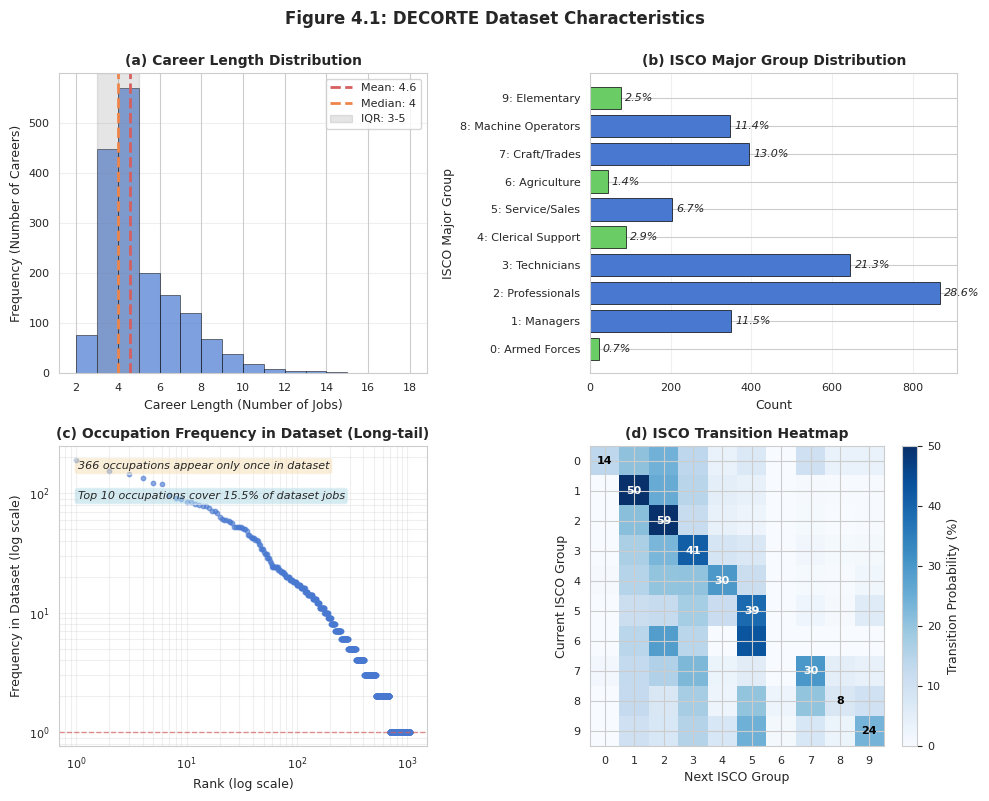


✓ Figure 4.1 generated successfully
✓ Saved as PDF and PNG (300 DPI)


In [ ]:
# Figure 4.1: Dataset Characteristics (2×2 subplot grid)
print("\n" + "="*60)
print("FIGURE 4.1: DATASET CHARACTERISTICS")
print("="*60)

# Convert decorte_dataset to pandas DataFrame for easier manipulation
df_decorte = decorte_dataset['train'].to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Figure 4.1: DECORTE Dataset Characteristics', fontsize=12, fontweight='bold', y=0.995)

# Define consistent color palette
primary_color = sns.color_palette("muted")[0]  # steelblue-like
secondary_color = sns.color_palette("muted")[3]  # red-like
tertiary_color = sns.color_palette("muted")[1]  # orange-like
highlight_color = sns.color_palette("muted")[2]  # green-like
gray_color = 'gray'

# Subplot (a): Career Length Distribution
ax_a = axes[0, 0]
career_lengths = df_decorte['number_of_experiences'].values
mean_length = np.mean(career_lengths)
median_length = np.median(career_lengths)

# Histogram
counts, bins, patches = ax_a.hist(career_lengths, bins=range(int(career_lengths.min()), int(career_lengths.max())+2), 
                                    color=primary_color, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add vertical lines for mean and median
ax_a.axvline(mean_length, color=secondary_color, linestyle='--', linewidth=2, label=f'Mean: {mean_length:.1f}')
ax_a.axvline(median_length, color=tertiary_color, linestyle='--', linewidth=2, label=f'Median: {median_length:.0f}')

# Add shaded region for 25th-75th percentiles
p25, p75 = np.percentile(career_lengths, [25, 75])
ax_a.axvspan(p25, p75, alpha=0.2, color=gray_color, label=f'IQR: {p25:.0f}-{p75:.0f}')

ax_a.set_xlabel('Career Length (Number of Jobs)', fontsize=9)
ax_a.set_ylabel('Frequency (Number of Careers)', fontsize=9)
ax_a.set_title('(a) Career Length Distribution', fontsize=10, fontweight='bold')
ax_a.legend(loc='upper right', fontsize=8)
ax_a.tick_params(axis='both', labelsize=8)
ax_a.grid(axis='y', alpha=0.3)

# Subplot (b): ISCO Major Group Distribution
ax_b = axes[0, 1]
isco_counts = occupations_with_levels['isco_level1'].value_counts().sort_index()
isco_labels_map = {
    0: '0: Armed Forces',
    1: '1: Managers',
    2: '2: Professionals',
    3: '3: Technicians',
    4: '4: Clerical Support',
    5: '5: Service/Sales',
    6: '6: Agriculture',
    7: '7: Craft/Trades',
    8: '8: Machine Operators',
    9: '9: Elementary'
}
isco_labels = [isco_labels_map[int(i)] for i in isco_counts.index]
total_jobs = isco_counts.sum()
percentages = (isco_counts.values / total_jobs * 100)

# Color bars based on percentage (highlight underrepresented <5%)
colors = [highlight_color if pct < 5 else primary_color for pct in percentages]

bars = ax_b.barh(isco_labels, isco_counts.values, color=colors, edgecolor='black', linewidth=0.5)

# Add percentage labels
for i, (count, pct) in enumerate(zip(isco_counts.values, percentages)):
    ax_b.text(count + 10, i, f'{pct:.1f}%', va='center', fontsize=8, style='italic')

ax_b.set_xlabel('Count', fontsize=9)
ax_b.set_ylabel('ISCO Major Group', fontsize=9)
ax_b.set_title('(b) ISCO Major Group Distribution', fontsize=10, fontweight='bold')
ax_b.tick_params(axis='both', labelsize=8)
ax_b.grid(axis='x', alpha=0.3)

# Subplot (c): Occupation Frequency in Dataset (Long-tail)
ax_c = axes[1, 0]

# Count occupation occurrences in the Decorte dataset
occupation_counts = []
for _, row in df_decorte.iterrows():
    for i in range(int(row['number_of_experiences'])):
        esco_uri = row[f'ESCO_uri_{i}']
        if pd.notna(esco_uri):
            occ_data = occupations_with_levels[occupations_with_levels['conceptUri'] == esco_uri]
            if not occ_data.empty:
                occupation_counts.append(occ_data.iloc[0]['preferredLabel'])

# Get frequency distribution
occ_freq = pd.Series(occupation_counts).value_counts().sort_values(ascending=False)
ranks = np.arange(1, len(occ_freq) + 1)
frequencies = occ_freq.values

ax_c.scatter(ranks, frequencies, s=10, alpha=0.6, color=primary_color)
ax_c.set_xscale('log')
ax_c.set_yscale('log')

# Add horizontal line at frequency=1
ax_c.axhline(1, color=secondary_color, linestyle='--', linewidth=1, alpha=0.7)

# Annotations
singletons = (frequencies == 1).sum()
top10_coverage = frequencies[:10].sum() / frequencies.sum() * 100
ax_c.text(0.05, 0.95, f'{singletons} occupations appear only once in dataset', 
          transform=ax_c.transAxes, fontsize=8, va='top', style='italic',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax_c.text(0.05, 0.85, f'Top 10 occupations cover {top10_coverage:.1f}% of dataset jobs', 
          transform=ax_c.transAxes, fontsize=8, va='top', style='italic',
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

ax_c.set_xlabel('Rank (log scale)', fontsize=9)
ax_c.set_ylabel('Frequency in Dataset (log scale)', fontsize=9)
ax_c.set_title('(c) Occupation Frequency in Dataset (Long-tail)', fontsize=10, fontweight='bold')
ax_c.tick_params(axis='both', labelsize=8)
ax_c.grid(True, alpha=0.3, which='both')

# Subplot (d): ISCO Transition Heatmap
ax_d = axes[1, 1]

# Build transition matrix
transition_matrix = np.zeros((10, 10))
for _, row in df_decorte.iterrows():
    isco_sequence = []
    for i in range(int(row['number_of_experiences'])):
        esco_uri = row[f'ESCO_uri_{i}']
        if pd.notna(esco_uri):
            occ_data = occupations_with_levels[occupations_with_levels['conceptUri'] == esco_uri]
            if not occ_data.empty:
                isco_sequence.append(int(occ_data.iloc[0]['isco_level1']))
    
    # Count transitions
    for j in range(len(isco_sequence) - 1):
        current_isco = isco_sequence[j]
        next_isco = isco_sequence[j + 1]
        transition_matrix[current_isco, next_isco] += 1

# Convert to probabilities (row-wise normalization)
row_sums = transition_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # Avoid division by zero
transition_probs = transition_matrix / row_sums * 100

# Plot heatmap
im = ax_d.imshow(transition_probs, cmap='Blues', aspect='auto', vmin=0, vmax=50)

# Add colorbar
cbar = plt.colorbar(im, ax=ax_d)
cbar.set_label('Transition Probability (%)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Set ticks and labels
ax_d.set_xticks(range(10))
ax_d.set_yticks(range(10))
ax_d.set_xticklabels(range(10), fontsize=8)
ax_d.set_yticklabels(range(10), fontsize=8)
ax_d.set_xlabel('Next ISCO Group', fontsize=9)
ax_d.set_ylabel('Current ISCO Group', fontsize=9)
ax_d.set_title('(d) ISCO Transition Heatmap', fontsize=10, fontweight='bold')

# Annotate diagonal cells (within-group transitions)
for i in range(10):
    if transition_probs[i, i] > 0:
        ax_d.text(i, i, f'{transition_probs[i, i]:.0f}', 
                  ha='center', va='center', color='white' if transition_probs[i, i] > 25 else 'black',
                  fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Save figure in both formats
fig.savefig('figure_4_1_dataset_characteristics.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figure_4_1_dataset_characteristics.png', dpi=300, bbox_inches='tight')

print("\n✓ Figure 4.1 generated successfully")
print("✓ Saved as PDF and PNG (300 DPI)")
print("="*60)



FIGURE 4.1: DATASET CHARACTERISTICS


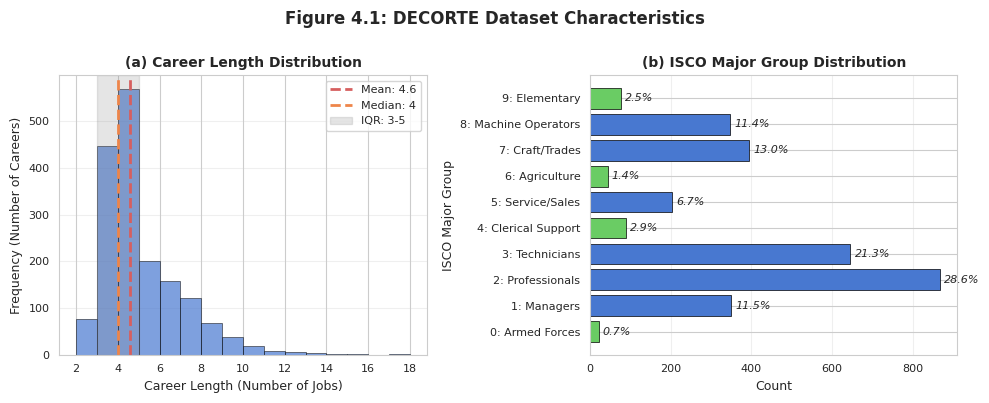


✓ Figure 4.1 generated successfully
✓ Saved as PDF and PNG (300 DPI)


In [59]:
# Figure 4.1: Dataset Characteristics (1×2 subplot grid)
print("\n" + "="*60)
print("FIGURE 4.1: DATASET CHARACTERISTICS")
print("="*60)

# Convert decorte_dataset to pandas DataFrame for easier manipulation
df_decorte = decorte_dataset['train'].to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Figure 4.1: DECORTE Dataset Characteristics', fontsize=12, fontweight='bold', y=0.995)

# Define consistent color palette
primary_color = sns.color_palette("muted")[0]  # steelblue-like
secondary_color = sns.color_palette("muted")[3]  # red-like
tertiary_color = sns.color_palette("muted")[1]  # orange-like
highlight_color = sns.color_palette("muted")[2]  # green-like
gray_color = 'gray'

# Subplot (a): Career Length Distribution
ax_a = axes[0]
career_lengths = df_decorte['number_of_experiences'].values
mean_length = np.mean(career_lengths)
median_length = np.median(career_lengths)

# Histogram
counts, bins, patches = ax_a.hist(career_lengths, bins=range(int(career_lengths.min()), int(career_lengths.max())+2), 
                                    color=primary_color, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add vertical lines for mean and median
ax_a.axvline(mean_length, color=secondary_color, linestyle='--', linewidth=2, label=f'Mean: {mean_length:.1f}')
ax_a.axvline(median_length, color=tertiary_color, linestyle='--', linewidth=2, label=f'Median: {median_length:.0f}')

# Add shaded region for 25th-75th percentiles
p25, p75 = np.percentile(career_lengths, [25, 75])
ax_a.axvspan(p25, p75, alpha=0.2, color=gray_color, label=f'IQR: {p25:.0f}-{p75:.0f}')

ax_a.set_xlabel('Career Length (Number of Jobs)', fontsize=9)
ax_a.set_ylabel('Frequency (Number of Careers)', fontsize=9)
ax_a.set_title('(a) Career Length Distribution', fontsize=10, fontweight='bold')
ax_a.legend(loc='upper right', fontsize=8)
ax_a.tick_params(axis='both', labelsize=8)
ax_a.grid(axis='y', alpha=0.3)

# Subplot (b): ISCO Major Group Distribution
ax_b = axes[1]
isco_counts = occupations_with_levels['isco_level1'].value_counts().sort_index()
isco_labels_map = {
    0: '0: Armed Forces',
    1: '1: Managers',
    2: '2: Professionals',
    3: '3: Technicians',
    4: '4: Clerical Support',
    5: '5: Service/Sales',
    6: '6: Agriculture',
    7: '7: Craft/Trades',
    8: '8: Machine Operators',
    9: '9: Elementary'
}
isco_labels = [isco_labels_map[int(i)] for i in isco_counts.index]
total_jobs = isco_counts.sum()
percentages = (isco_counts.values / total_jobs * 100)

# Color bars based on percentage (highlight underrepresented <5%)
colors = [highlight_color if pct < 5 else primary_color for pct in percentages]

bars = ax_b.barh(isco_labels, isco_counts.values, color=colors, edgecolor='black', linewidth=0.5)

# Add percentage labels
for i, (count, pct) in enumerate(zip(isco_counts.values, percentages)):
    ax_b.text(count + 10, i, f'{pct:.1f}%', va='center', fontsize=8, style='italic')

ax_b.set_xlabel('Count', fontsize=9)
ax_b.set_ylabel('ISCO Major Group', fontsize=9)
ax_b.set_title('(b) ISCO Major Group Distribution', fontsize=10, fontweight='bold')
ax_b.tick_params(axis='both', labelsize=8)
ax_b.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Save figure in both formats
fig.savefig('figure_4_1_dataset_characteristics.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figure_4_1_dataset_characteristics.png', dpi=300, bbox_inches='tight')

print("\n✓ Figure 4.1 generated successfully")
print("✓ Saved as PDF and PNG (300 DPI)")
print("="*60)


In [60]:
occ_skill_relations

,occupationUri,relationType,skillType,skillUri
0,http://data.europa.eu/esco/occupation/00030d09...,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...
1,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...
2,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...
3,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/47ed1d37-971b...
4,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/591dd514-735b...
...,...,...,...,...
128999,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/df487cde-38d4...
129000,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/e975b791-b488...
129001,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/ed938748-60ae...
129002,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/f30a7ea4-77dd...



FIGURE 4.2: ESCO SKILL TAXONOMY STRUCTURE


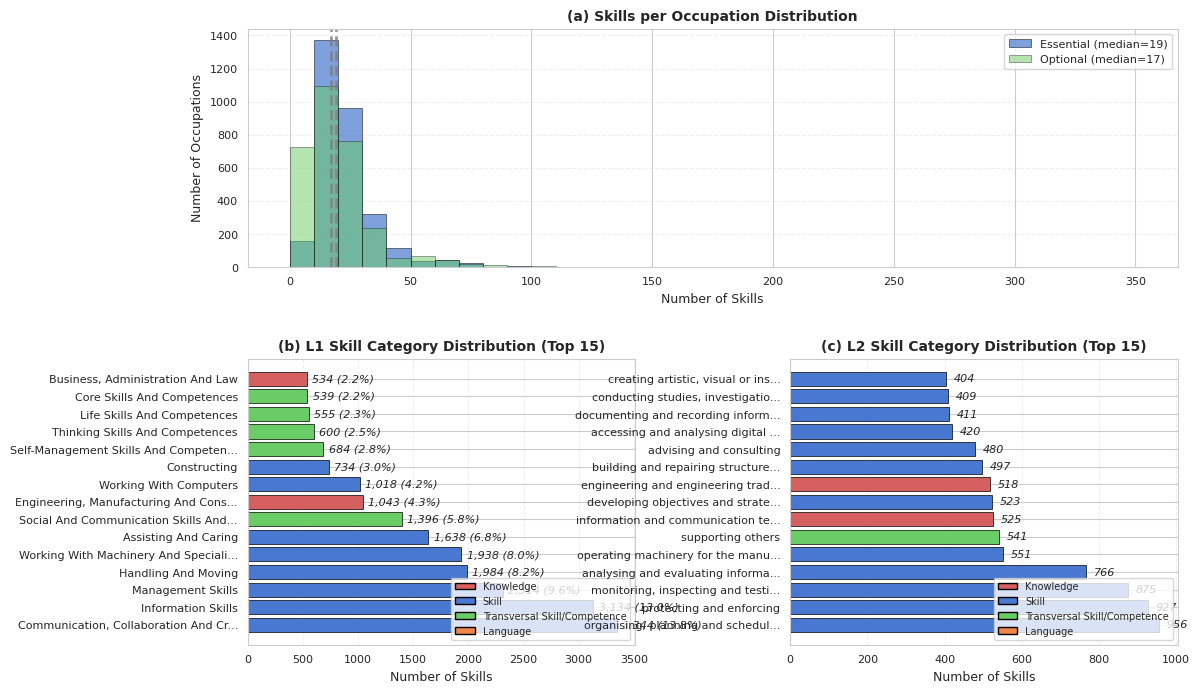


✓ Figure 4.2 generated successfully
✓ Saved as PDF and PNG (300 DPI)


In [61]:
# Figure 4.2: ESCO Skill Taxonomy Structure
print("\n" + "="*60)
print("FIGURE 4.2: ESCO SKILL TAXONOMY STRUCTURE")
print("="*60)

# Create figure with custom grid layout: 1 plot on top (spanning 2 columns), 2 plots below
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.4)
ax_a = fig.add_subplot(gs[0, :])  # Top row, spanning both columns
ax_b = fig.add_subplot(gs[1, 0])  # Bottom left
ax_c = fig.add_subplot(gs[1, 1])  # Bottom right

# ============================================================================
# Subplot (a): Skills per Occupation Distribution
# ============================================================================
# Prepare occupations_df with skill counts
# Merge occupation-skill relations with occupation data
occ_with_skills = occ_skill_relations.merge(
    occupations_with_levels[['conceptUri', 'preferredLabel', 'isco_level1', 'isco_level2', 'isco_level3', 'isco_level4']], 
    left_on='occupationUri', 
    right_on='conceptUri', 
    how='left'
)

# Group by occupation and aggregate skills by relation type
occupations_df = occ_with_skills.groupby('occupationUri').agg({
    'preferredLabel': 'first',
    'isco_level1': 'first',
    'isco_level2': 'first',
    'isco_level3': 'first',
    'isco_level4': 'first',
    'skillUri': lambda x: list(x)
}).reset_index()

# Separate essential and optional skills
essential_skills = occ_with_skills[occ_with_skills['relationType'] == 'essential'].groupby('occupationUri')['skillUri'].apply(list).reset_index()
essential_skills.columns = ['occupationUri', 'essential_skills']

optional_skills = occ_with_skills[occ_with_skills['relationType'] == 'optional'].groupby('occupationUri')['skillUri'].apply(list).reset_index()
optional_skills.columns = ['occupationUri', 'optional_skills']

# Merge essential and optional skills into occupations_df
occupations_df = occupations_df.merge(essential_skills, on='occupationUri', how='left')
occupations_df = occupations_df.merge(optional_skills, on='occupationUri', how='left')

# Fill NaN with empty lists
occupations_df['essential_skills'] = occupations_df['essential_skills'].apply(lambda x: x if isinstance(x, list) else [])
occupations_df['optional_skills'] = occupations_df['optional_skills'].apply(lambda x: x if isinstance(x, list) else [])

# Calculate skills per occupation
occupations_df['total_skills'] = occupations_df['essential_skills'].apply(lambda x: len(x) if isinstance(x, list) else 0) + \
                                  occupations_df['optional_skills'].apply(lambda x: len(x) if isinstance(x, list) else 0)
occupations_df['essential_count'] = occupations_df['essential_skills'].apply(lambda x: len(x) if isinstance(x, list) else 0)
occupations_df['optional_count'] = occupations_df['optional_skills'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Calculate medians
median_essential = occupations_df['essential_count'].median()
median_optional = occupations_df['optional_count'].median()

# Create histogram with consistent colors
bins = range(0, occupations_df['total_skills'].max() + 10, 10)
ax_a.hist(occupations_df['essential_count'], bins=bins, alpha=0.7, color='#4878CF', 
          label=f'Essential (median={median_essential:.0f})', edgecolor='black', linewidth=0.5)
ax_a.hist(occupations_df['optional_count'], bins=bins, alpha=0.5, color='#6ACC65', 
          label=f'Optional (median={median_optional:.0f})', edgecolor='black', linewidth=0.5)

# Add median lines in gray
ax_a.axvline(median_essential, color='#7F7F7F', linestyle='--', linewidth=2, alpha=0.8)
ax_a.axvline(median_optional, color='#7F7F7F', linestyle='--', linewidth=2, alpha=0.8)

ax_a.set_xlabel('Number of Skills', fontsize=9)
ax_a.set_ylabel('Number of Occupations', fontsize=9)
ax_a.set_title('(a) Skills per Occupation Distribution', fontsize=10, fontweight='bold')
ax_a.legend(fontsize=8, loc='upper right')
ax_a.tick_params(labelsize=8)
ax_a.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================================================
# Subplot (b): L1 Skill Category Distribution (Top 15)
# ============================================================================
skills_df = df_h.copy()

# Count skills per L1 category (level1_label)
l1_counts = skills_df['level1_label'].value_counts()

# Get top 15 (excluding "Other" from the display)
l1_display = l1_counts.head(15)

# Define consistent colors for pillar categories using muted palette
l1_colors = {
    'knowledge': '#D65F5F',
    'skills': '#4878CF',
    'transversal skills and competences': '#6ACC65',
    'language skills and knowledge': '#EE854A'
}

# Map L1 to pillar for coloring
l1_to_pillar = skills_df.groupby('level1_label')['pillar_label'].first().to_dict()
colors_b = [l1_colors.get(l1_to_pillar.get(cat, '').lower(), '#7F7F7F') for cat in l1_display.index]

# Create bar chart
bars = ax_b.barh(range(len(l1_display)), l1_display.values, color=colors_b, edgecolor='black', linewidth=0.5)

# Add value labels
for i, (count, cat) in enumerate(zip(l1_display.values, l1_display.index)):
    percentage = (count / l1_counts.sum()) * 100
    ax_b.text(count + 50, i, f'{count:,} ({percentage:.1f}%)', 
              va='center', fontsize=8, fontstyle='italic')

ax_b.set_yticks(range(len(l1_display)))
# Truncate long labels for L1 to prevent overlap
l1_labels = [cat.title()[:35] + '...' if len(cat.title()) > 35 else cat.title() for cat in l1_display.index]
ax_b.set_yticklabels(l1_labels, fontsize=7)
ax_b.set_xlabel('Number of Skills', fontsize=9)
ax_b.set_title('(b) L1 Skill Category Distribution (Top 15)', fontsize=10, fontweight='bold')
ax_b.tick_params(labelsize=8)
ax_b.grid(axis='x', alpha=0.3, linestyle='--')

# Add legend for pillar colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D65F5F', edgecolor='black', label='Knowledge'),
    Patch(facecolor='#4878CF', edgecolor='black', label='Skill'),
    Patch(facecolor='#6ACC65', edgecolor='black', label='Transversal Skill/Competence'),
    Patch(facecolor='#EE854A', edgecolor='black', label='Language')
]
ax_b.legend(handles=legend_elements, fontsize=7, loc='lower right')

# ============================================================================
# Subplot (c): L2 Skill Category Distribution (Top 15)
# ============================================================================
skills_df = df_h.copy()

# Count skills per L2 category (level2_label)
l2_counts = skills_df['level2_label'].value_counts()

# Get top 15 (excluding "Other" from the display)
l2_display = l2_counts.head(15)

# Map L2 categories to their pillar for coloring
l2_to_pillar = skills_df.groupby('level2_label')['pillar_label'].first().to_dict()

colors_c = [l1_colors.get(l2_to_pillar.get(cat, '').lower(), '#7F7F7F') for cat in l2_display.index]

# Create horizontal bar chart
y_pos = range(len(l2_display))
bars = ax_c.barh(y_pos, l2_display.values, color=colors_c, edgecolor='black', linewidth=0.5)

# Add value labels
for i, count in enumerate(l2_display.values):
    ax_c.text(count + 20, i, f'{count:,}', va='center', fontsize=8, fontstyle='italic')

# Truncate long labels for L2 to prevent overlap
labels = [label[:32] + '...' if len(label) > 32 else label for label in l2_display.index]
ax_c.set_yticks(y_pos)
ax_c.set_yticklabels(labels, fontsize=7)
ax_c.set_xlabel('Number of Skills', fontsize=9)
ax_c.set_title('(c) L2 Skill Category Distribution (Top 15)', fontsize=10, fontweight='bold')
ax_c.tick_params(labelsize=8)
ax_c.grid(axis='x', alpha=0.3, linestyle='--')

# Add legend for pillar colors
ax_c.legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

# Save figure in both formats
fig.savefig('figure_4_2_esco_skill_taxonomy.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figure_4_2_esco_skill_taxonomy.png', dpi=300, bbox_inches='tight')

print("\n✓ Figure 4.2 generated successfully")
print("✓ Saved as PDF and PNG (300 DPI)")
print("="*60)



FIGURE 4.2: ESCO OCCUPATION-SKILL RELATION CHARACTERISTICS


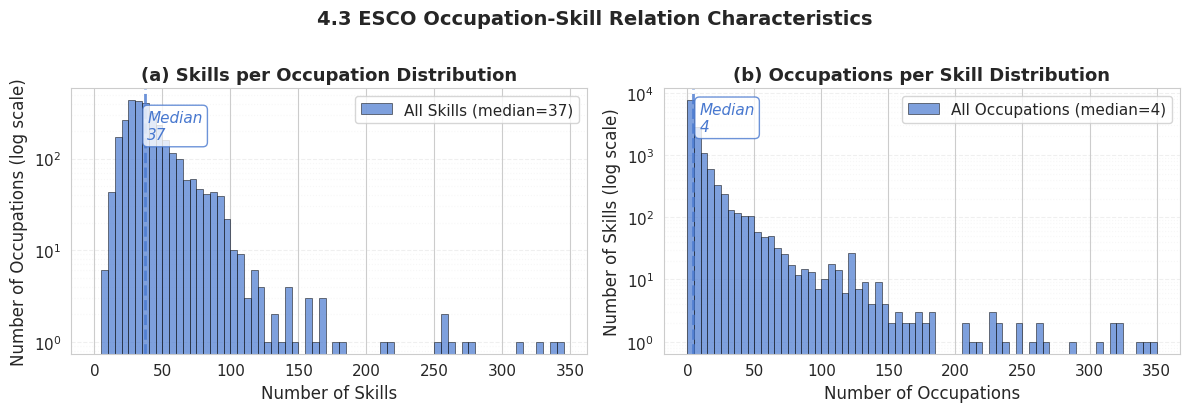


✓ Figure 4.2 generated successfully
✓ Saved as PDF and PNG (300 DPI)


In [86]:
# Figure 4.2: ESCO Occupation-Skill Relation Characteristics
print("\n" + "="*60)
print("FIGURE 4.2: ESCO OCCUPATION-SKILL RELATION CHARACTERISTICS")
print("="*60)

# Create figure with 1x2 subplots
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 4))

# Add main title
fig.suptitle('4.3 ESCO Occupation-Skill Relation Characteristics', fontsize=14, fontweight='bold', y=1.02)

# ============================================================================
# Subplot (a): Skills per Occupation Distribution
# ============================================================================
# Prepare occupations_df with skill counts
# Merge occupation-skill relations with occupation data
occ_with_skills = occ_skill_relations.merge(
    occupations_with_levels[['conceptUri', 'preferredLabel', 'isco_level1', 'isco_level2', 'isco_level3', 'isco_level4']], 
    left_on='occupationUri', 
    right_on='conceptUri', 
    how='left'
)

# Group by occupation and count total skills
occupations_df = occ_with_skills.groupby('occupationUri').agg({
    'preferredLabel': 'first',
    'isco_level1': 'first',
    'isco_level2': 'first',
    'isco_level3': 'first',
    'isco_level4': 'first',
    'skillUri': 'count'
}).reset_index()
occupations_df.columns = ['occupationUri', 'preferredLabel', 'isco_level1', 'isco_level2', 'isco_level3', 'isco_level4', 'total_skills']

# Calculate median
median_skills = occupations_df['total_skills'].median()

# Create histogram
bins = range(0, occupations_df['total_skills'].max() + 5, 5)
ax_a.hist(occupations_df['total_skills'], bins=bins, alpha=0.7, color='#4878CF', 
          label=f'All Skills (median={median_skills:.0f})', edgecolor='black', linewidth=0.5)

# Add median line with annotation
ax_a.axvline(median_skills, color='#4878CF', linestyle='--', linewidth=2, alpha=0.8)
ax_a.text(median_skills + 2, ax_a.get_ylim()[1] * 0.5, f'Median\n{median_skills:.0f}', 
          fontsize=11, fontstyle='italic', color='#4878CF', va='center', ha='left', 
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#4878CF', alpha=0.8))

# Use log scale for y-axis
ax_a.set_yscale('log')

ax_a.set_xlabel('Number of Skills', fontsize=12)
ax_a.set_ylabel('Number of Occupations (log scale)', fontsize=12)
ax_a.set_title('(a) Skills per Occupation Distribution', fontsize=13, fontweight='bold')
ax_a.legend(fontsize=11, loc='upper right')
ax_a.tick_params(labelsize=11)
ax_a.grid(axis='y', alpha=0.3, linestyle='--', which='major')
ax_a.grid(axis='y', alpha=0.15, linestyle=':', which='minor')

# ============================================================================
# Subplot (b): Occupations per Skill Distribution
# ============================================================================
# Count occupations per skill
skill_occ_counts = occ_skill_relations.groupby('skillUri')['occupationUri'].count().reset_index()
skill_occ_counts.columns = ['skillUri', 'occupation_count']

# Calculate median
median_occupations = skill_occ_counts['occupation_count'].median()

# Create histogram
bins_occ = range(0, int(skill_occ_counts['occupation_count'].max()) + 5, 5)
ax_b.hist(skill_occ_counts['occupation_count'], bins=bins_occ, alpha=0.7, color='#4878CF', 
          label=f'All Occupations (median={median_occupations:.0f})', edgecolor='black', linewidth=0.5)

# Add median line with annotation
ax_b.axvline(median_occupations, color='#4878CF', linestyle='--', linewidth=2, alpha=0.8)
ax_b.text(median_occupations + 5, ax_b.get_ylim()[1] * 0.5, f'Median\n{median_occupations:.0f}', 
          fontsize=11, fontstyle='italic', color='#4878CF', va='center', ha='left', 
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#4878CF', alpha=0.8))

# Use log scale for y-axis
ax_b.set_yscale('log')

ax_b.set_xlabel('Number of Occupations', fontsize=12)
ax_b.set_ylabel('Number of Skills (log scale)', fontsize=12)
ax_b.set_title('(b) Occupations per Skill Distribution', fontsize=13, fontweight='bold')
ax_b.legend(fontsize=11, loc='upper right')
ax_b.tick_params(labelsize=11)
ax_b.grid(axis='y', alpha=0.3, linestyle='--', which='major')
ax_b.grid(axis='y', alpha=0.15, linestyle=':', which='minor')

plt.tight_layout()
plt.show()

# Save figure in both formats
fig.savefig('figure_4_2_esco_skill_taxonomy.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figure_4_2_esco_skill_taxonomy.png', dpi=300, bbox_inches='tight')

print("\n✓ Figure 4.2 generated successfully")
print("✓ Saved as PDF and PNG (300 DPI)")
print("="*60)


In [70]:
occupations_with_levels.head()

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level1,isco_level2,isco_level3,isco_level4
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2024-01-25T11:28:50.295Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,metal drawing machine technician\nmetal drawin...,NaN,released,2024-01-23T10:09:32.099Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,8,81,812,8121
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,inspector of precision instruments\nprecision ...,NaN,released,2024-01-25T15:00:12.188Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Precision device inspectors make sure precisio...,7543.10.3,7,75,754,7543
3,Occupation,http://data.europa.eu/esco/occupation/0022f466...,3155,air traffic safety technician,air traffic safety electronics hardware specia...,NaN,released,2024-01-29T16:01:13.998Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Air traffic safety technicians provide technic...,3155.1,3,31,315,3155
4,Occupation,http://data.europa.eu/esco/occupation/002da35b...,2431,hospitality revenue manager,hospitality revenues manager\nyield manager\nh...,NaN,released,2024-01-11T10:28:45.871Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Hospitality revenue managers maximise revenue ...,2431.9,2,24,243,2431


In [74]:
pivot_table = occ_skill_relations.merge(
    occupations_with_levels[['conceptUri', 'isco_level1']], 
    how='left', left_on='occupationUri', right_on='conceptUri').merge(
    skills[['conceptUri', 'preferredLabel']], 
    how='left', 
    left_on='skillUri', 
    right_on='conceptUri').pivot_table(
        index='preferredLabel',
        columns='isco_level1',
        values='occupationUri',
        aggfunc='nunique'
    )

pivot_table['All'] = pivot_table.sum(axis=1)

In [84]:
pivot_table.sort_values('All', ascending=False).iloc[:15].astype('Int64').fillna(0)

isco_level1,0,1,2,3,4,5,6,7,8,9,All
preferredLabel,,,,,,,,,,,
create solutions to problems,0,113,66,97,10,11,3,37,9,1,347
use different communication channels,13,71,66,60,20,76,7,6,16,7,342
manage staff,5,219,47,38,6,13,2,3,3,1,337
manage budgets,4,184,86,31,2,9,3,3,1,0,323
keep records of work progress,0,3,4,78,1,0,0,130,103,4,323
have computer literacy,0,82,58,108,15,26,1,11,16,2,319
quality standards,1,21,56,35,3,2,0,100,97,1,316
troubleshoot,0,2,51,41,0,1,0,112,96,3,306
speak different languages,0,60,149,49,6,16,5,1,0,0,286


In [79]:
pivot_table_decorte = occ_skill_relations.query('occupationUri in @all_esco_uris').merge(
    occupations_with_levels[['conceptUri', 'isco_level1']], 
    how='left', left_on='occupationUri', right_on='conceptUri').merge(
    skills[['conceptUri', 'preferredLabel']], 
    how='left', 
    left_on='skillUri', 
    right_on='conceptUri').pivot_table(
        index='preferredLabel',
        columns='isco_level1',
        values='occupationUri',
        aggfunc='nunique'
    )

pivot_table_decorte['All'] = pivot_table_decorte.sum(axis=1)

In [85]:
pivot_table_decorte.sort_values('All', ascending=False).iloc[:15].fillna(0)

isco_level1,0,1,2,3,4,5,6,7,8,9,All
preferredLabel,,,,,,,,,,,
manage budgets,1.0,112.0,62.0,25.0,2.0,5.0,0.0,1.0,0.0,0.0,208.0
manage staff,1.0,108.0,27.0,23.0,3.0,8.0,0.0,1.0,0.0,1.0,172.0
use different communication channels,10.0,35.0,38.0,30.0,10.0,35.0,0.0,2.0,5.0,5.0,170.0
perform project management,0.0,37.0,88.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,134.0
create solutions to problems,0.0,37.0,35.0,32.0,5.0,9.0,1.0,10.0,1.0,1.0,131.0
develop professional network,0.0,37.0,70.0,16.0,1.0,3.0,0.0,4.0,0.0,0.0,131.0
train employees,0.0,38.0,37.0,36.0,0.0,11.0,0.0,6.0,1.0,0.0,129.0
identify customer's needs,0.0,14.0,34.0,11.0,12.0,35.0,0.0,7.0,0.0,0.0,113.0
recruit employees,0.0,70.0,13.0,23.0,1.0,4.0,0.0,2.0,0.0,0.0,113.0


In [147]:
occ_skill_relations

,occupationUri,relationType,skillType,skillUri
0,http://data.europa.eu/esco/occupation/00030d09...,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...
1,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...
2,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...
3,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/47ed1d37-971b...
4,http://data.europa.eu/esco/occupation/00030d09...,essential,skill/competence,http://data.europa.eu/esco/skill/591dd514-735b...
...,...,...,...,...
128999,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/df487cde-38d4...
129000,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/e975b791-b488...
129001,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/ed938748-60ae...
129002,http://data.europa.eu/esco/occupation/ffc292f1...,optional,skill/competence,http://data.europa.eu/esco/skill/f30a7ea4-77dd...


In [127]:
l2_to_pillar

{'Albanian': 'language skills and knowledge',
 'Ancient Greek': 'language skills and knowledge',
 'Arabic': 'language skills and knowledge',
 'Armenian': 'language skills and knowledge',
 'Azerbaijani': 'language skills and knowledge',
 'Basque': 'language skills and knowledge',
 'Belarusian': 'language skills and knowledge',
 'Bengali': 'language skills and knowledge',
 'Berber': 'language skills and knowledge',
 'Bihari': 'language skills and knowledge',
 'Bosnian': 'language skills and knowledge',
 'Bulgarian': 'language skills and knowledge',
 'Catalan': 'language skills and knowledge',
 'Chinese': 'language skills and knowledge',
 'Croatian': 'language skills and knowledge',
 'Czech': 'language skills and knowledge',
 'Danish': 'language skills and knowledge',
 'Dutch': 'language skills and knowledge',
 'English': 'language skills and knowledge',
 'Estonian': 'language skills and knowledge',
 'Finnish': 'language skills and knowledge',
 'French': 'language skills and knowledge',
 

In [115]:
isco_labels_map


{0: '0: Armed Forces',
 1: '1: Managers',
 2: '2: Professionals',
 3: '3: Technicians',
 4: '4: Clerical Support',
 5: '5: Service/Sales',
 6: '6: Agriculture',
 7: '7: Craft/Trades',
 8: '8: Machine Operators',
 9: '9: Elementary'}

In [116]:
isco_counts.index

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object', name='isco_level1')